<a href="https://colab.research.google.com/github/brunamportoDS/H-M-segmentation/blob/main/H_M_Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# H&M Customer Segmentation: Finding Shopper Types Through Unsupervised Learning

## Introduction

Every time someone buys a t-shirt or a pair of socks from H&M, that purchase becomes a single row in a massive transaction log. The retailer's public dataset contains roughly 31 million such rows, covering about 1.37 million customers and 105,000 products over two years (September 2018 to September 2020). On its own, a transaction log tells you what was sold, but not who the customers are as shoppers.

This project aims to answer: if we summarize each customer by how and what they buy, do natural groups emerge? Are there recognizable shopper types hiding in the data, such as bargain hunters, fashion enthusiasts, or parents shopping for their kids?

Because we have no labels telling us which customer belongs to which type, this is a ideal task for unsupervised learning. We use principal component analysis and matrix factorization to find the main dimensions of variation among customers, and clustering to group similar customers together.

## Methodology

### 1. Data Acquisition

The dataset comes from H&M's 2022 Kaggle competition and arrives as three CSV files: a transaction log, a customer table, and an article (product) table. The full download also includes a folder of product images totaling tens of gigabytes, but we skip those entirely. Our analysis is built on shopping behavior and product attributes, not on what the clothes look like, so the three CSVs (about 3.5 GB) are all we need.

In [1]:
# Install kaggle CLI
!pip install kaggle --quiet

# Upload your kaggle.json API token
# Get it from Kaggle: Account -> Settings -> Create New API Token
from google.colab import files
files.upload()  # Select kaggle.json when prompted

# Move credentials to the expected location
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download only the three CSVs we need (skip images and sample_submission)
COMPETITION = "h-and-m-personalized-fashion-recommendations"
!kaggle competitions download -c $COMPETITION -f articles.csv
!kaggle competitions download -c $COMPETITION -f customers.csv
!kaggle competitions download -c $COMPETITION -f transactions_train.csv

# Unzip (Kaggle delivers each as a .zip)
!unzip -o articles.csv.zip
!unzip -o customers.csv.zip
!unzip -o transactions_train.csv.zip

# Verify
!ls -lh *.csv

Saving kaggle.json to kaggle.json
100% 4.26M/4.26M [00:01<00:00, 4.26MB/s]

100% 97.9M/97.9M [00:04<00:00, 21.4MB/s]

100% 584M/584M [00:22<00:00, 26.8MB/s]

Archive:  articles.csv.zip
  inflating: articles.csv            
Archive:  customers.csv.zip
  inflating: customers.csv           
Archive:  transactions_train.csv.zip
  inflating: transactions_train.csv  
-rw-r--r-- 1 root root  35M Jan 17  2022 articles.csv
-rw-r--r-- 1 root root 198M Jan 17  2022 customers.csv
-rw-r--r-- 1 root root 3.3G Jan 17  2022 transactions_train.csv


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 2. Sampling the Customer Base

Working with 1.37 million customers and 31 million transactions is unwieldy, so we draw a random sample of 10,000 customers and fix the random seed so the sample is reproducible. We restrict the sample to customers with at least 5 transactions. This matters because many of our features (such as how varied a customer's color choices are) need a reasonable purchase history to be meaningful, and a customer with a single purchase cannot tell us much about their habits.

The full customer base is heavily skewed: the median customer made just 9 purchases while the mean is 23, pulled up by a small number of very heavy buyers. The 5-transaction threshold keeps about 68% of customers (925,558 of them), so we are not discarding much. One consequence worth stating plainly: our findings describe engaged H&M customers rather than the entire base, since we deliberately exclude one-time and very low-activity shoppers.

To keep memory manageable, we read the large transaction file in two passes. The first pass only counts transactions per customer, and the second pass loads only the transactions belonging to our sampled customers.

In [3]:
import pandas as pd
import numpy as np

# Parameters (adjust if your team decided differently at the kickoff)
MIN_TRANSACTIONS = 5      # minimum transactions for a customer to be eligible
SAMPLE_SIZE = 10_000      # number of customers to sample
RANDOM_SEED = 42          # for reproducibility

# Pass 1: count transactions per customer (low memory, only loads customer_id column)
chunk_counts_list = []
for chunk in pd.read_csv(
    'transactions_train.csv',
    usecols=['customer_id'],
    chunksize=1_000_000
):
    chunk_counts = chunk['customer_id'].value_counts().reset_index()
    chunk_counts.columns = ['customer_id', 'count']
    chunk_counts_list.append(chunk_counts)

customer_txn_counts = (
    pd.concat(chunk_counts_list, ignore_index=True)
      .groupby('customer_id')['count']
      .sum()
)

print(f"Total customers in transactions: {len(customer_txn_counts):,}")
print(f"Transaction count distribution:")
print(customer_txn_counts.describe())

# Filter and sample
eligible = customer_txn_counts[customer_txn_counts >= MIN_TRANSACTIONS].index
print(f"\nEligible customers (>= {MIN_TRANSACTIONS} txns): {len(eligible):,}")

np.random.seed(RANDOM_SEED)
customer_sample = np.random.choice(eligible, size=SAMPLE_SIZE, replace=False)
customer_sample_set = set(customer_sample)  # for fast lookup later

print(f"Sampled customers: {len(customer_sample):,}")

Total customers in transactions: 1,362,281
Transaction count distribution:
count    1.362281e+06
mean     2.333463e+01
std      3.924225e+01
min      1.000000e+00
25%      3.000000e+00
50%      9.000000e+00
75%      2.700000e+01
max      1.895000e+03
Name: count, dtype: float64

Eligible customers (>= 5 txns): 925,558
Sampled customers: 10,000


### Validating the Sample

Random sampling guarantees representativeness in expectation, but it is worth verifying empirically. We compare the sample to the eligible population on three dimensions where bias would be most visible: age, transaction count, and club member status. We use Kolmogorov-Smirnov tests for the two continuous variables and a chi-square test for the categorical one. With true random sampling at n = 10,000, all three should be statistically indistinguishable.

In [4]:
# Recompute customer_counts
customer_counts = pd.read_csv('transactions_train.csv',
                              usecols=['customer_id']).groupby('customer_id').size()
print(f"Loaded counts for {len(customer_counts):,} customers")
print(f"Customers with >=5 transactions: {(customer_counts >= 5).sum():,}")

Loaded counts for 1,362,281 customers
Customers with >=5 transactions: 925,558


In [6]:
# HL: c/p files to local drive location "/content/drive/MyDrive/hm_project_new" to bypass write permission error caused by the cell above
import os

new_folder = "/content/drive/MyDrive/hm_project_new"

os.makedirs(new_folder, exist_ok=True)

customer_counts.to_pickle(f"{new_folder}/customer_counts.pkl")

AGE (eligible population vs 10K sample)
  Eligible: mean=36.01, median=31, std=13.66, n=925,558
  Sample:   mean=36.09, median=31, std=13.61, n=10,000
  KS test:  stat=0.0059, p=0.8872
  PASS: distributions match

TRANSACTION COUNT (eligible population vs 10K sample)
  Eligible: mean=33.26, median=18, std=44.26
  Sample:   mean=33.92, median=18, std=46.00
  KS test:  stat=0.0077, p=0.6007
  PASS: distributions match

CLUB MEMBER STATUS
  Eligible proportions: {'ACTIVE': 0.9557, 'PRE-CREATE': 0.044, 'LEFT CLUB': 0.0003}
  Sample proportions:   {'ACTIVE': 0.957, 'PRE-CREATE': 0.0427, 'LEFT CLUB': 0.0003}
  Chi-square: stat=0.39, p=0.8226
  PASS: distributions match



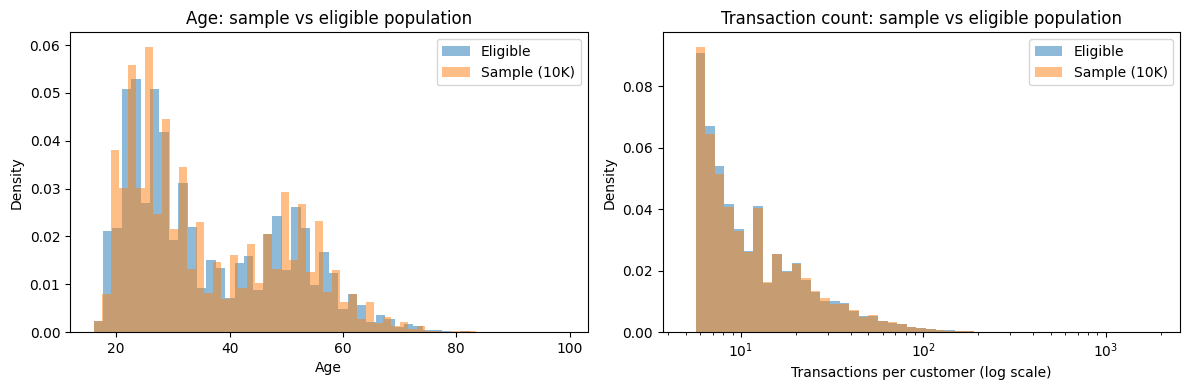

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Prereqs: features and customer_counts should both be in memory from your earlier cells.
# If you get a NameError, reload features from parquet and we'll handle customer_counts separately.

# Demographics for all customers (small file)
customers_all = pd.read_csv('customers.csv',
                            usecols=['customer_id', 'age', 'club_member_status'])

eligible_ids = set(customer_counts[customer_counts >= 5].index)
sample_ids = set(features.index)
eligible_demo = customers_all[customers_all['customer_id'].isin(eligible_ids)]
sample_demo = customers_all[customers_all['customer_id'].isin(sample_ids)]

# ---- AGE ----
print("AGE (eligible population vs 10K sample)")
print(f"  Eligible: mean={eligible_demo['age'].mean():.2f}, "
      f"median={eligible_demo['age'].median():.0f}, "
      f"std={eligible_demo['age'].std():.2f}, n={len(eligible_demo):,}")
print(f"  Sample:   mean={sample_demo['age'].mean():.2f}, "
      f"median={sample_demo['age'].median():.0f}, "
      f"std={sample_demo['age'].std():.2f}, n={len(sample_demo):,}")
ks_stat, ks_p = stats.ks_2samp(eligible_demo['age'].dropna(),
                                sample_demo['age'].dropna())
print(f"  KS test:  stat={ks_stat:.4f}, p={ks_p:.4f}")
print(f"  {'PASS: distributions match' if ks_p > 0.05 else 'FAIL: distributions differ'}\n")

# ---- TRANSACTION COUNT ----
elig_counts = customer_counts[customer_counts.index.isin(eligible_ids)]
samp_counts = customer_counts[customer_counts.index.isin(sample_ids)]
print("TRANSACTION COUNT (eligible population vs 10K sample)")
print(f"  Eligible: mean={elig_counts.mean():.2f}, "
      f"median={elig_counts.median():.0f}, std={elig_counts.std():.2f}")
print(f"  Sample:   mean={samp_counts.mean():.2f}, "
      f"median={samp_counts.median():.0f}, std={samp_counts.std():.2f}")
ks_stat, ks_p = stats.ks_2samp(elig_counts, samp_counts)
print(f"  KS test:  stat={ks_stat:.4f}, p={ks_p:.4f}")
print(f"  {'PASS: distributions match' if ks_p > 0.05 else 'FAIL: distributions differ'}\n")

# ---- CLUB MEMBER STATUS ----
elig_club = eligible_demo['club_member_status'].value_counts()
samp_club = sample_demo['club_member_status'].value_counts()
print("CLUB MEMBER STATUS")
print(f"  Eligible proportions: "
      f"{(elig_club / elig_club.sum()).round(4).to_dict()}")
print(f"  Sample proportions:   "
      f"{(samp_club / samp_club.sum()).round(4).to_dict()}")
combined = pd.DataFrame({'eligible': elig_club, 'sample': samp_club}).fillna(0)
chi2, p, _, _ = stats.chi2_contingency(combined.values)
print(f"  Chi-square: stat={chi2:.2f}, p={p:.4f}")
print(f"  {'PASS: distributions match' if p > 0.05 else 'FAIL: distributions differ'}\n")

# ---- VISUAL COMPARISON ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(eligible_demo['age'].dropna(), bins=50, alpha=0.5,
             label='Eligible', density=True)
axes[0].hist(sample_demo['age'].dropna(), bins=50, alpha=0.5,
             label='Sample (10K)', density=True)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Density')
axes[0].set_title('Age: sample vs eligible population')
axes[0].legend()

bins = np.logspace(np.log10(5), np.log10(elig_counts.max()), 50)
axes[1].hist(elig_counts, bins=bins, alpha=0.5, label='Eligible', density=True)
axes[1].hist(samp_counts, bins=bins, alpha=0.5, label='Sample (10K)', density=True)
axes[1].set_xlabel('Transactions per customer (log scale)')
axes[1].set_ylabel('Density')
axes[1].set_xscale('log')
axes[1].set_title('Transaction count: sample vs eligible population')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_sample_validation.png', dpi=150, bbox_inches='tight')
plt.show()

To verify that the sample is representative of the eligible population it was drawn from, we compared the two on three dimensions where bias would be most visible. Mean age is 36.0 in both groups, with identical medians of 31 and standard deviations within 0.1 of each other (Kolmogorov-Smirnov p = 0.89). Mean transaction count is 33.3 in the eligible population and 33.9 in the sample, with identical medians of 18 (KS p = 0.60). Club membership proportions are nearly identical, with 95.6% of eligible customers and 95.7% of sampled customers in the ACTIVE category (chi-square p = 0.82). All three tests confirm the sample is statistically indistinguishable from the eligible population. The remaining limitation, that the sample describes engaged customers (those with at least 5 transactions) rather than the full H&M customer base, is a deliberate scope choice rather than a sampling artifact.

### 3. Filtering Transactions and Joining Product Metadata

After filtering the transaction log down to our 10,000 sampled customers, we are left with about 339,000 transactions, an average of roughly 34 per customer. We then attach each transaction's product attributes (product group, color, department, and garment type) by joining with the article table. Every transaction matched a product record, so there were no gaps in the metadata.

In [10]:
# Load article metadata (small, fits in memory easily)
articles = pd.read_csv('articles.csv')
print(f"Articles loaded: {len(articles):,}")

# Filter transactions in chunks (second pass)
filtered_chunks = []
for chunk in pd.read_csv(
    'transactions_train.csv',
    chunksize=1_000_000,
    parse_dates=['t_dat']
):
    filtered = chunk[chunk['customer_id'].isin(customer_sample_set)]
    if len(filtered) > 0:
        filtered_chunks.append(filtered)

transactions = pd.concat(filtered_chunks, ignore_index=True)
print(f"Filtered transactions: {len(transactions):,}")
print(f"Date range: {transactions['t_dat'].min().date()} to {transactions['t_dat'].max().date()}")

# Join with article metadata (only the columns we need)
transactions = transactions.merge(
    articles[['article_id', 'product_group_name', 'colour_group_name',
              'department_name', 'garment_group_name']],
    on='article_id',
    how='left'
)
print(f"After join: {len(transactions):,} rows, {len(transactions.columns)} columns")
print(f"Missing metadata rows: {transactions['product_group_name'].isna().sum():,}")

Articles loaded: 105,542
Filtered transactions: 339,217
Date range: 2018-09-20 to 2020-09-22
After join: 339,217 rows, 9 columns
Missing metadata rows: 0


### 4. Building the Customer-by-Category Matrix

For the matrix factorization stage, we reshape the data into a customer-by-category matrix: one row per customer, one column per product group (19 in total), with each cell counting how many items that customer bought in that category. The result is sparse, about 76% of cells are zero, because the typical customer buys from only four or five of the nineteen categories. That sparsity is exactly what makes this matrix a natural candidate for matrix completion, where we estimate what a customer's interest in an unobserved category might be.

In [11]:
# Use product_group_name as the category level (19 categories, good granularity)
customer_category_matrix = (
    transactions
    .groupby(['customer_id', 'product_group_name'])
    .size()
    .unstack(fill_value=0)
)

# Ensure all sampled customers appear (even if any have zero matched rows)
customer_category_matrix = customer_category_matrix.reindex(customer_sample, fill_value=0)

print(f"Matrix shape: {customer_category_matrix.shape}")
print(f"Categories: {customer_category_matrix.columns.tolist()}")
sparsity = (customer_category_matrix == 0).sum().sum() / customer_category_matrix.size
print(f"Sparsity: {sparsity:.1%} of cells are zero")

# Save for Track 2
customer_category_matrix.to_parquet('customer_category_matrix.parquet')
print("\nSaved: customer_category_matrix.parquet")

Matrix shape: (10000, 19)
Categories: ['Accessories', 'Bags', 'Cosmetic', 'Fun', 'Furniture', 'Garment Full body', 'Garment Lower body', 'Garment Upper body', 'Garment and Shoe care', 'Interior textile', 'Items', 'Nightwear', 'Shoes', 'Socks & Tights', 'Stationery', 'Swimwear', 'Underwear', 'Underwear/nightwear', 'Unknown']
Sparsity: 75.8% of cells are zero

Saved: customer_category_matrix.parquet


### 5. Engineering Customer Features

We summarize each customer with a set of behavioral features built from their transactions:

- **Recency** (days since last purchase), **frequency** (number of transactions), and **monetary value** (total spend), the classic measures of customer engagement.
- **Product and department variety** (counts of distinct items and departments).
- **Color and garment diversity**, measured with Shannon entropy. Entropy is simply a measure of how varied a set of choices is: a customer who always buys black scores low, while a customer who buys evenly across many colors scores high.
- **Average unit price**, a rough proxy for whether a customer leans toward cheaper or pricier items.
- **Age**, taken from the customer table.

A few practical notes: the prices in this dataset are normalized rather than given in real currency, so the monetary figures are relative rather than dollar amounts. Age was missing for 59 of the 10,000 customers, which we handle at the clustering stage.

In [12]:
from scipy.stats import entropy

# Reference date for recency (use max transaction date in sample)
REFERENCE_DATE = transactions['t_dat'].max()
print(f"Reference date for recency: {REFERENCE_DATE.date()}")

def shannon_entropy(values):
    """Compute Shannon entropy in bits. Drop NaN before computing."""
    values = values.dropna()
    if len(values) == 0:
        return 0.0
    proportions = values.value_counts(normalize=True)
    return entropy(proportions, base=2)

# Group once for efficiency
grouped = transactions.groupby('customer_id')

# Build features dataframe
features = pd.DataFrame(index=customer_sample)
features.index.name = 'customer_id'

features['recency_days'] = (REFERENCE_DATE - grouped['t_dat'].max()).dt.days
features['frequency'] = grouped.size()
features['monetary'] = grouped['price'].sum()
features['n_unique_products'] = grouped['article_id'].nunique()
features['n_unique_departments'] = grouped['department_name'].nunique()
features['color_entropy'] = grouped['colour_group_name'].apply(shannon_entropy)
features['garment_entropy'] = grouped['product_group_name'].apply(shannon_entropy)
features['mean_unit_price'] = grouped['price'].mean()

# Customer age from customers.csv (also keep club_member_status for validation labels)
customers = pd.read_csv('customers.csv', usecols=['customer_id', 'age', 'club_member_status'])
customers_sampled = customers[customers['customer_id'].isin(customer_sample_set)].set_index('customer_id')

features = features.join(customers_sampled[['age']], how='left')

# Validation labels (for Track 3 to use as held-out interpretation labels)
validation_labels = customers_sampled[['age', 'club_member_status']]

print(f"\nFeature matrix shape: {features.shape}")
print(f"Features: {features.columns.tolist()}")
print(f"\nSummary statistics:")
print(features.describe())
print(f"\nMissing values per feature:")
print(features.isna().sum())

# Save for Track 3
features.to_parquet('customer_features.parquet')
validation_labels.to_parquet('validation_labels.parquet')
print("\nSaved: customer_features.parquet, validation_labels.parquet")

Reference date for recency: 2020-09-22

Feature matrix shape: (10000, 9)
Features: ['recency_days', 'frequency', 'monetary', 'n_unique_products', 'n_unique_departments', 'color_entropy', 'garment_entropy', 'mean_unit_price', 'age']

Summary statistics:
       recency_days     frequency      monetary  n_unique_products  \
count  10000.000000  10000.000000  10000.000000       10000.000000   
mean     172.348200     33.921700      0.945214          28.945700   
std      186.365749     45.995662      1.455795          36.417712   
min        0.000000      5.000000      0.027322           1.000000   
25%       31.000000      9.000000      0.236725           8.000000   
50%       91.000000     18.000000      0.481847          16.000000   
75%      262.000000     40.000000      1.053233          35.000000   
max      733.000000    959.000000     26.384203         613.000000   

       n_unique_departments  color_entropy  garment_entropy  mean_unit_price  \
count          10000.000000   10000.

## Exploratory Data Analysis

Before applying any models, we examine the data to understand its shape: how the features are distributed, how they relate to one another, and what structure might already be visible. These observations guide the modeling choices that follow, particularly around scaling and dimensionality reduction.

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Consistent style for the blog
sns.set_style('whitegrid')
sns.set_context('notebook')

### Transaction Frequency

Among our sampled customers, purchase frequency is strongly right-skewed: the median customer made 18 purchases while the mean is 34, with a long tail stretching past 900 for the heaviest buyers. This skew is typical of retail data and has a practical consequence. If we feed raw counts into clustering, the handful of extreme buyers will dominate the distance calculations. We therefore log-transform the count-based features before clustering so that the bulk of ordinary customers are not overshadowed.

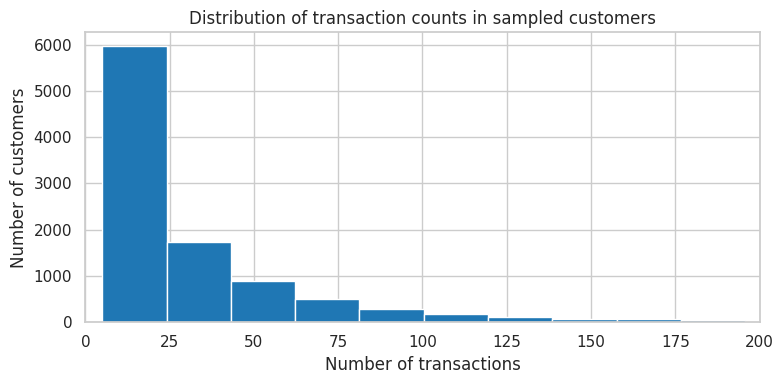

Customers with 100+ transactions (heavy buyers): 631
Median: 18, Mean: 33.9


In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(features['frequency'], bins=50, edgecolor='white')
ax.set_xlabel('Number of transactions')
ax.set_ylabel('Number of customers')
ax.set_title('Distribution of transaction counts in sampled customers')
ax.set_xlim(0, 200)  # truncate for readability; note the long tail
plt.tight_layout()
plt.savefig('eda_transaction_counts.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Customers with 100+ transactions (heavy buyers): {(features['frequency'] >= 100).sum():,}")
print(f"Median: {features['frequency'].median():.0f}, Mean: {features['frequency'].mean():.1f}")

### Customer Age

The age distribution is distinctly bimodal, with one peak in the mid-20s and a second, smaller peak around 50. The dip between them, near age 40, is pronounced. This is a genuine structural feature of H&M's customer base rather than an artifact of sampling. It also raises a question we will return to after clustering: do our behavior-based segments line up with these age groups, or does age cut across them?

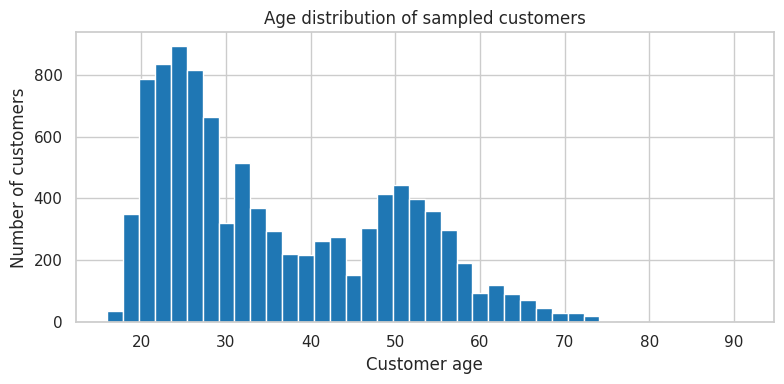

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(features['age'].dropna(), bins=40, edgecolor='white')
ax.set_xlabel('Customer age')
ax.set_ylabel('Number of customers')
ax.set_title('Age distribution of sampled customers')
plt.tight_layout()
plt.savefig('eda_age.png', dpi=150, bbox_inches='tight')
plt.show()

### Product Category Popularity

Purchases are heavily concentrated in clothing. Garment Upper body items dominate, followed by Garment Lower body and Garment Full body, while categories like furniture, stationery, and cosmetics sit near zero. This concentration is worth noting for the matrix factorization: the rarely purchased categories become nearly empty columns in the customer-by-category matrix and contribute little signal.

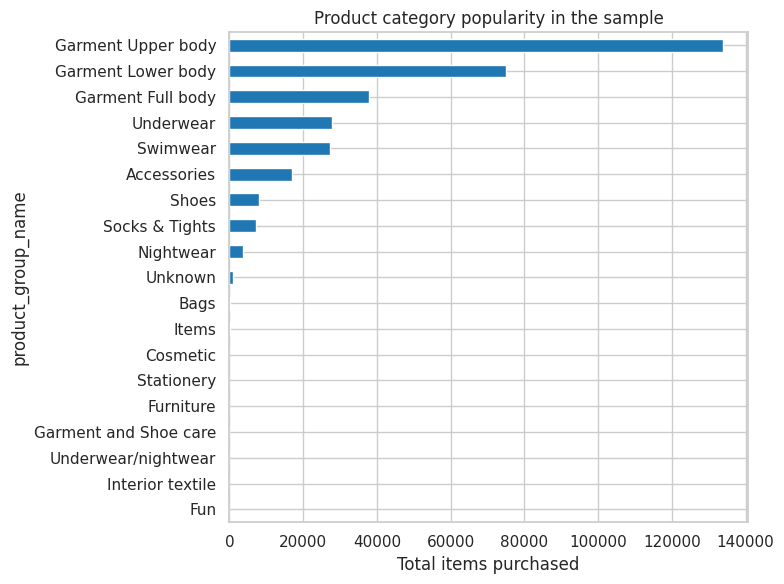

In [16]:
category_totals = customer_category_matrix.sum(axis=0).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
category_totals.plot(kind='barh', ax=ax)
ax.set_xlabel('Total items purchased')
ax.set_title('Product category popularity in the sample')
plt.tight_layout()
plt.savefig('eda_category_popularity.png', dpi=150, bbox_inches='tight')
plt.show()

### Purchases Over Time

Plotting transactions by month reveals seasonality, with peaks in late spring and early summer in both years. The low values at the very start and end of the series are simply partial months (the data begins on September 20, 2018 and ends on September 22, 2020). Notably, there is no dramatic collapse in spring 2020 despite the onset of the pandemic, consistent with online-heavy retail holding up during that period.

/tmp/ipykernel_10700/406700404.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = transactions.set_index('t_dat').resample('M').size()


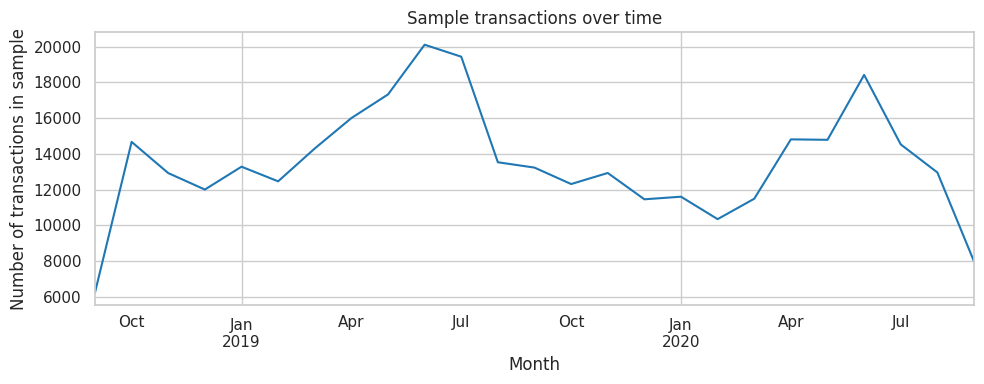

In [17]:
monthly = transactions.set_index('t_dat').resample('M').size()

fig, ax = plt.subplots(figsize=(10, 4))
monthly.plot(ax=ax)
ax.set_xlabel('Month')
ax.set_ylabel('Number of transactions in sample')
ax.set_title('Sample transactions over time')
plt.tight_layout()
plt.savefig('eda_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

### Feature Distributions

Viewing all features side by side highlights how differently they are scaled and shaped. The count-based features (frequency, monetary value, unique products) are sharply right-skewed, while the entropy features are more bell-shaped and the price feature is roughly symmetric. Because the features live on different scales, we standardize them before applying PCA and clustering, and log-transform the skewed count features first. One small quirk appears in the entropy plots: spikes at round values like 0 and 1, which come from customers with very few purchases, whose entropy can only take a few discrete values.

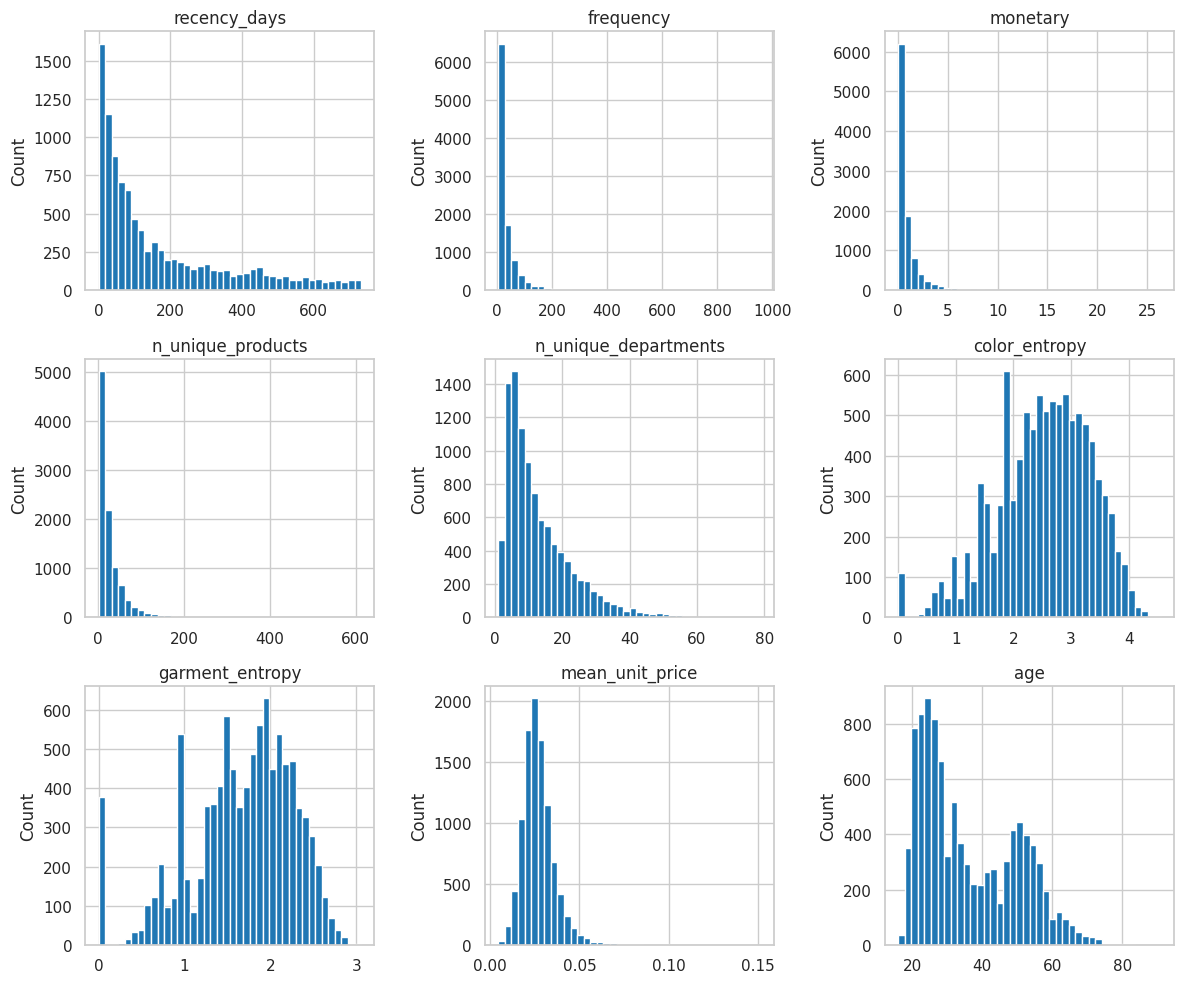

In [18]:
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
for ax, col in zip(axes.flatten(), features.columns):
    ax.hist(features[col].dropna(), bins=40, edgecolor='white')
    ax.set_title(col)
    ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('eda_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### Feature Correlations

The four engagement features (frequency, monetary value, unique products, and unique departments) are extremely highly correlated, between 0.88 and 0.98, meaning they are largely measuring the same underlying thing: overall engagement. This redundancy is precisely what principal component analysis is designed to compress, and it strongly suggests that the first principal component will be an engagement axis.

By contrast, average unit price and age are nearly uncorrelated with engagement and with each other, so they represent independent dimensions of customer variation. In other words, how much someone shops tells us almost nothing about how old they are or how expensive their tastes run.

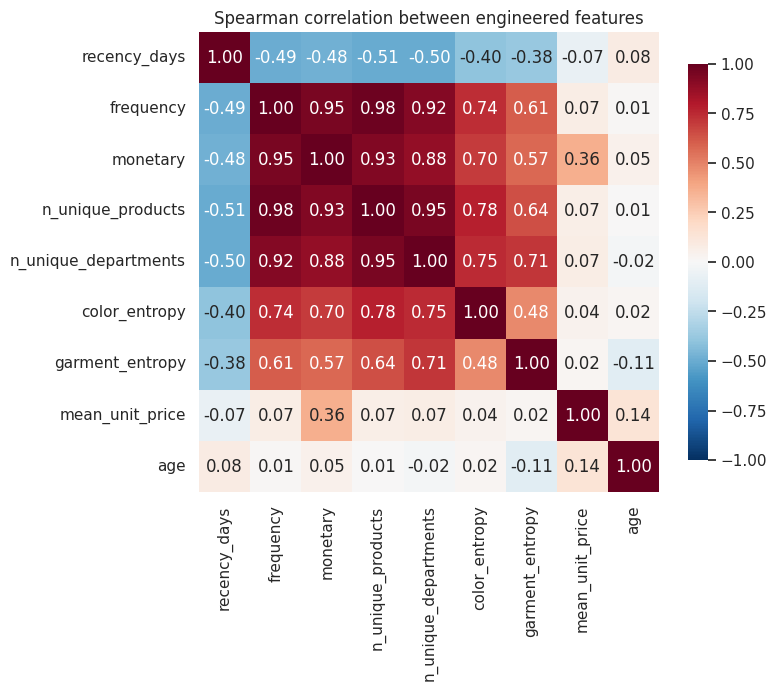

In [19]:
# Use Spearman to handle the right-skewed distributions without log-transforming
corr = features.corr(method='spearman')

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Spearman correlation between engineered features')
plt.tight_layout()
plt.savefig('eda_feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

### 6. Composition Features (What Customers Buy)


The behavioral features above capture how much and how varied a customer's shopping is, but not what type of products they favor. To capture that, we add five composition features: the share of each customer's purchases falling in each high-level product group (Ladieswear, Menswear, Baby/Children, Sport, and Divided, H&M's younger fashion line).

This dimension turns out to be essential. Consider two customers who each made 40 purchases. On engagement features alone they look identical. But if one bought 40 children's items and the other bought 40 womenswear items, they are completely different shoppers, a parent versus a fashion buyer. Only the composition features can tell them apart.

In [20]:
print("index_group_name values:")
print(articles['index_group_name'].value_counts())
print("\nindex_name values:")
print(articles['index_name'].value_counts())

index_group_name values:
index_group_name
Ladieswear       39737
Baby/Children    34711
Divided          15149
Menswear         12553
Sport             3392
Name: count, dtype: int64

index_name values:
index_name
Ladieswear                        26001
Divided                           15149
Menswear                          12553
Children Sizes 92-140             12007
Children Sizes 134-170             9214
Baby Sizes 50-98                   8875
Ladies Accessories                 6961
Lingeries/Tights                   6775
Children Accessories, Swimwear     4615
Sport                              3392
Name: count, dtype: int64


In [21]:
INDEX_COL = 'index_group_name'  # switch to 'index_name' for the ~10-category version

# Add the index column to transactions if not already there (articles still in memory)
if INDEX_COL not in transactions.columns:
    transactions = transactions.merge(
        articles[['article_id', INDEX_COL]],
        on='article_id',
        how='left'
    )

# Proportion of each customer's purchases in each index group
index_props = (
    transactions
    .groupby(['customer_id', INDEX_COL])
    .size()
    .unstack(fill_value=0)
)
index_props = index_props.div(index_props.sum(axis=1), axis=0)  # row-normalize

# Clean column names
index_props.columns = ['pct_' + str(c).lower().replace(' ', '_').replace('/', '_')
                       for c in index_props.columns]

# Align to the sample and join
index_props = index_props.reindex(customer_sample, fill_value=0)
features = features.join(index_props, how='left')

print(f"New feature matrix shape: {features.shape}")
print(f"Added columns: {index_props.columns.tolist()}")
print(f"\nIndex proportion summary:")
print(features[index_props.columns].describe())

# Re-save for Track 3
features.to_parquet('customer_features.parquet')
print("\nRe-saved: customer_features.parquet")

New feature matrix shape: (10000, 14)
Added columns: ['pct_baby_children', 'pct_divided', 'pct_ladieswear', 'pct_menswear', 'pct_sport']

Index proportion summary:
       pct_baby_children   pct_divided  pct_ladieswear  pct_menswear  \
count       10000.000000  10000.000000    10000.000000  10000.000000   
mean            0.043076      0.223081        0.634545      0.057933   
std             0.136855      0.209223        0.252859      0.133727   
min             0.000000      0.000000        0.000000      0.000000   
25%             0.000000      0.055556        0.478261      0.000000   
50%             0.000000      0.176471        0.666667      0.000000   
75%             0.000000      0.333333        0.826087      0.048823   
max             1.000000      1.000000        1.000000      1.000000   

          pct_sport  
count  10000.000000  
mean       0.041365  
std        0.106201  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%        0.031250  
max        

In [23]:
!ls -lh '/content/drive/MyDrive/hm_project/'

total 108M
-rw------- 1 root root 746K May 31 20:23 customer_category_matrix.parquet
-rw------- 1 root root 104M May 31 20:19 customer_counts.pkl
-rw------- 1 root root 1.1M May 31 20:23 customer_features.parquet
-rw------- 1 root root  37K May 31 20:23 eda_age.png
-rw------- 1 root root  91K May 31 20:23 eda_category_popularity.png
-rw------- 1 root root 189K May 31 20:23 eda_feature_correlations.png
-rw------- 1 root root 146K May 31 20:23 eda_feature_distributions.png
-rw------- 1 root root  73K May 31 20:23 eda_monthly_trend.png
-rw------- 1 root root  57K May 31 20:23 eda_sample_validation.png
-rw------- 1 root root  43K May 31 20:23 eda_transaction_counts.png
-rw------- 1 root root 639K May 31 20:23 validation_labels.parquet


### Product Composition Across Customers

These three views of the composition features tell a consistent story. First, the minority categories (menswear, baby/children, and sport) show a clear specialist signature: most customers buy none at all, but a small group buys heavily, producing a spike at zero and a thin tail toward one. Second, when we assign each customer to their dominant category, about 80% are primarily womenswear shoppers, with much smaller groups specializing in divided, menswear, kids, or sport. Third, customers are genuinely concentrated in their buying: almost no one spreads evenly across categories, and around 1,200 customers buy from a single group exclusively.

Together these patterns predict a two-layer segmentation. The composition features will carve off the specialist minorities (a parent segment, a menswear segment, and so on), while the behavioral features subdivide the large womenswear majority into types based on engagement, price, and variety.

In [24]:
# If your session restarted, reload first:
# features = pd.read_parquet('customer_features.parquet')

pct_cols = ['pct_ladieswear', 'pct_divided', 'pct_menswear', 'pct_baby_children', 'pct_sport']

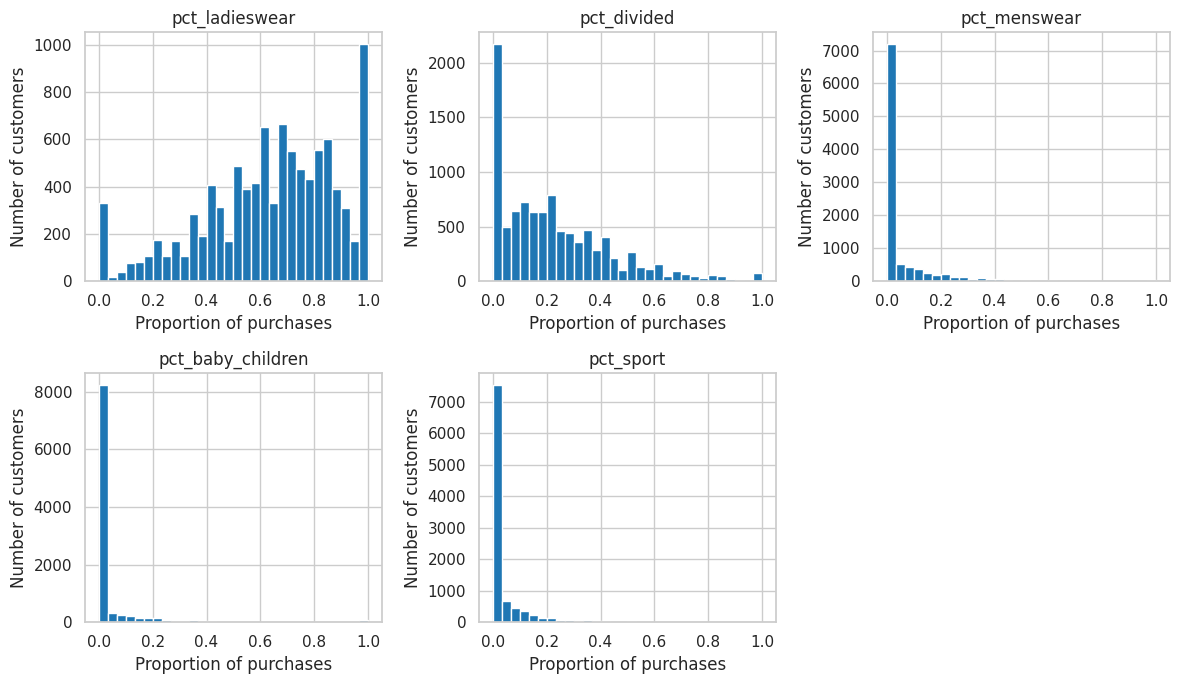

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, col in zip(axes.flatten(), pct_cols):
    ax.hist(features[col], bins=30, edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('Proportion of purchases')
    ax.set_ylabel('Number of customers')
axes.flatten()[-1].axis('off')  # hide the unused 6th panel
plt.tight_layout()
plt.savefig('eda_composition_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

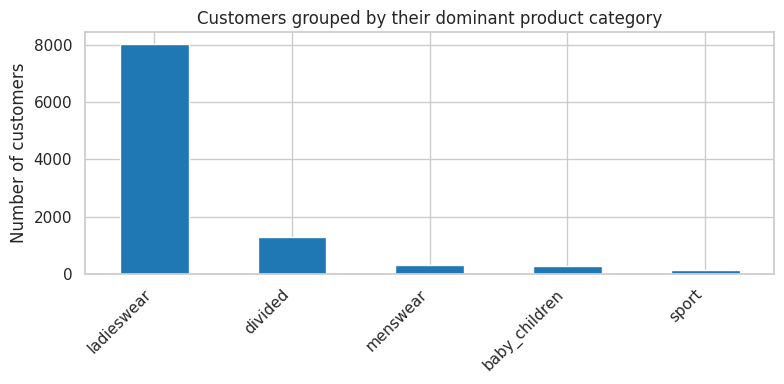

ladieswear       8039
divided          1268
menswear          293
baby_children     258
sport             142
Name: count, dtype: int64


In [26]:
# Assign each customer to whichever index group is their largest share
dominant_group = features[pct_cols].idxmax(axis=1).str.replace('pct_', '')
group_counts = dominant_group.value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
group_counts.plot(kind='bar', ax=ax)
ax.set_ylabel('Number of customers')
ax.set_title('Customers grouped by their dominant product category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('eda_dominant_group.png', dpi=150, bbox_inches='tight')
plt.show()

print(group_counts)

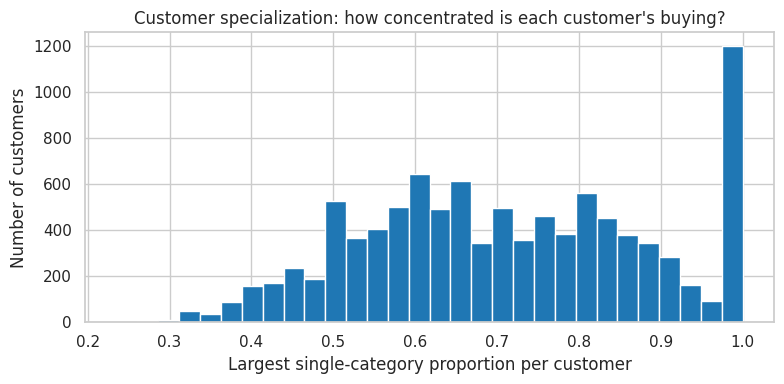

Customers with 80%+ in one category: 34.7%
Customers with 50%+ in one category: 90.4%


In [27]:
# How concentrated is each customer's buying? (largest single-category share)
max_pct = features[pct_cols].max(axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(max_pct, bins=30, edgecolor='white')
ax.set_xlabel('Largest single-category proportion per customer')
ax.set_ylabel('Number of customers')
ax.set_title('Customer specialization: how concentrated is each customer\'s buying?')
plt.tight_layout()
plt.savefig('eda_specialization.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Customers with 80%+ in one category: {(max_pct >= 0.8).mean():.1%}")
print(f"Customers with 50%+ in one category: {(max_pct >= 0.5).mean():.1%}")

## Theoretical Background

This project uses four unsupervised methods. Each tackles a different piece of the customer segmentation problem.

#### Principal Component Analysis

Principal Component Analysis (PCA) is an unsupervised method that reduces a dataset with many variables into a smaller set of new variables called principal components. Each principal component is a linear combination of the original features, constructed to capture as much variation in the data as possible. The first component points in the direction along which observations differ most; the second is orthogonal to it and captures the next most variation, and so on. This makes PCA useful for two purposes: visualizing high-dimensional data in two or three dimensions, and removing redundancy among correlated features before downstream modeling.

Because PCA is sensitive to feature scale, all variables are standardized to zero mean and unit variance before the decomposition. This ensures that no single feature dominates simply because it is measured on a larger numerical range. A common diagnostic is the scree plot, which shows the proportion of variance explained by each component. An "elbow" in this curve, where adding more components no longer captures meaningful additional variation, suggests a natural stopping point. The component loadings (the rotation matrix) describe how each original feature contributes to each principal component, which is what allows us to interpret what each component represents.

#### Singular Value Decomposition

Singular Value Decomposition (SVD) is the linear-algebra technique that underlies PCA. Any matrix X can be factored as X = U·S·V*, where U and V are matrices with orthonormal columns and S is a diagonal matrix of singular values. The singular values measure how much each direction contributes to the structure of the matrix, and they decrease in magnitude, so the first few capture the most important patterns. When SVD is applied directly to a customer-by-category matrix, the rows of V* describe latent product preference patterns (for example, a Ladieswear-heavy factor), while the rows of U describe how strongly each customer expresses each pattern.

SVD is closely related to PCA but is more naturally suited to sparse matrices like our customer-by-category purchase counts. Where PCA on engineered features helps us understand variation in customer behavior, SVD on the raw purchase matrix helps us discover the underlying preference patterns that drive what customers buy. The number of latent factors to retain is decided similarly to PCA: by examining how much variance each factor explains, and keeping enough to capture the bulk of the structure while keeping the representation compact.

#### Matrix Completion

Matrix completion is the task of estimating missing entries in a partially observed matrix. The idea is that if observations share a small number of underlying patterns (which SVD can reveal), then unseen entries can be predicted from those patterns. This is the foundation of many recommendation systems: by treating "products a customer has not yet bought" as missing data, we can predict the implied affinity from what other customers with similar behavior have bought.

The algorithm we use, following ISLR2 Chapter 12, is iterative. We first fill in missing entries with column means as an initial guess, then fit a low-rank SVD approximation to the resulting filled matrix, replace the missing entries with the values from that approximation, and repeat until the predictions stabilize. To evaluate how well the method works, we artificially mask a fraction of the observed entries (treating them as if they were missing), run the algorithm, and then compare the predicted values for those entries against their actual values. The resulting test mean squared error is compared to a simple column-mean baseline. If matrix completion meaningfully outperforms the baseline, it has captured real structure beyond what the average alone would tell us.



#### K-means Clustering
K-means clustering is an unsupervised learning method that partitions observations into a pre-specified number of groups, called clusters. In this project, each customer is represented by a set of numerical features, such as purchase frequency, total spending, product variety, entropy, age, and product-composition shares. K-means assigns customers to clusters so that customers within the same cluster are as similar as possible to one another. More formally, the algorithm tries to minimize the within-cluster sum of squares (WCSS), which is the total squarred distance between each customer and the centroid of their assigned cluster. This distance is usually measured using squared Euclidean distance. The cluster center, or centroid, represents the average profile of customers in that group.

A key decision in k-means is choosing the number of clusters, K. If K is too small, the model may combine meaningfully different customer types into overly broad groups. If K is too large, the model may create small or unstable clusters that are difficult to interpret. To choose K, we compare solutions using the WCSS plot and silhouette scores. The WCSS plot shows how within-cluster variation decreases as more clusters are added, while the silhouette score measures how well-separated the clusters are. In customer segmentation, the final choice of K should balance statistical criteria with interpretability, because the goal is not only to optimize a metric but also to identify meaningful and useful customer groups.

#### Hierarchical Clustering
Hierarchical clustering is another unsupervised method that groups observations based on similarity, but unlike k-means, it does not require choosing the number of clusters at the beginning. Instead, it builds a tree-like structure that shows how observations are gradually joined together. In agglomerative hierarchical clustering, each customer starts as its own cluster. The algorithm then repeatedly merges the two most similar clusters until all customers are joined into one large cluster. The result is visualized using a dendrogram, where lower merges indicate more similar customers or groups, and higher merges indicate less similar groups being combined.

An important choice in hierarchical clustering is the linkage method, which defines how the distance between two clusters is calculated. Single linkage uses the closest pair of observations between two clusters, complete linkage measures the distance between the farthest pair of observations in two clusters, average linkage uses the average pairwise distance between observations in two clusters, while Ward linkage merges clusters in a way that minimizes the increase in within-cluster variation. Different linkage methods can lead to different clustering results, so comparing them helps assess whether the customer segments are stable or highly dependent on the clustering method. After examining the dendrograms, we cut the tree at a chosen level to obtain a final number of clusters and then interpret those clusters using the original customer features.


## Dimensionality Reduction

In [28]:
from sklearn.preprocessing import StandardScaler

X= features.copy()

#Handle 59 missing age:
X['age']= X['age'].fillna(X['age'].median())

#Log transform skewed count features from EDA:
skewed_cols = ['frequency', 'monetary',
               'n_unique_products', 'n_unique_departments']
for col in skewed_cols:
  X[col]= np.log1p(X[col])

#Standardize data:
scaler= StandardScaler()
X_scaled = scaler.fit_transform(X)

Before applying principle component analysis (PCA), dataset is transformed t ensure that dimensionality reduction is meaningful and not dominated by scale or skewness effect. Some customer features, like purchase frequency, total monetary value, and counts of unique products, showed strong right skewness. To address that, logarithmic transformation is applied to these variables to help stabilize variance and reduce the influencers of extreme values. It also helps compressing large values and makes the distribution more symmetrical.

The dataset also contains varaibles that measured based on different scales, such as raw counts, proportion, or continuous demographic variables. PCA operates by identifying direction of maximum variance, features with larger numerical ranges would dominate the analysis. To prevent that, all variables are standardized to have mean zero and unit variance. That is to make sure each feature contribute equally throughout the analysis, allowing PCA to capture meaningful pattrns.

### PCA: Variance Explained


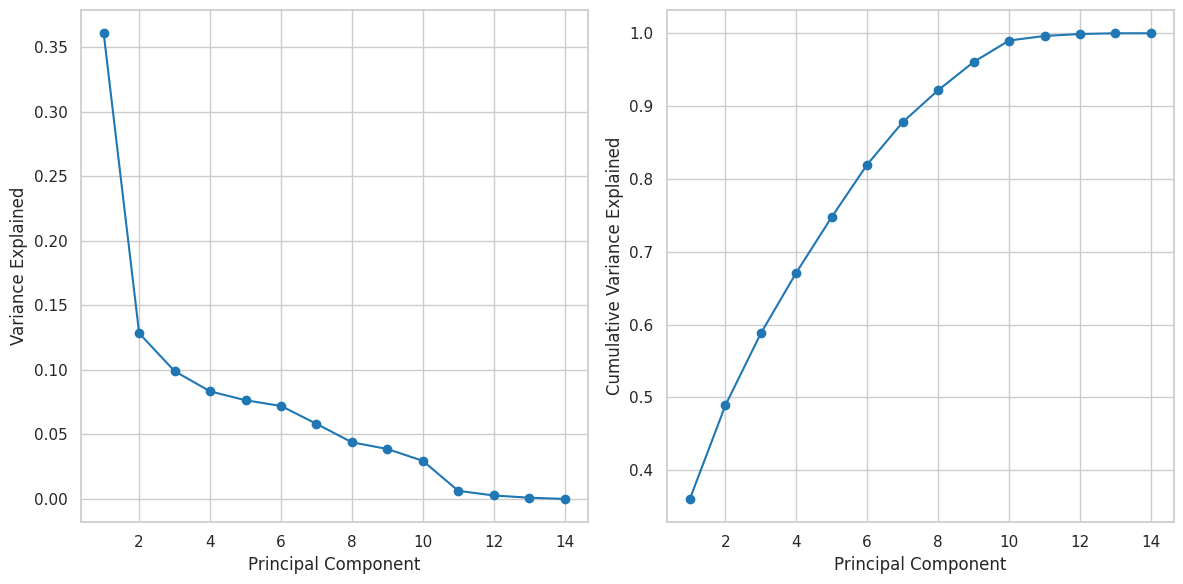

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#Run PCA:
pca= PCA()
X_pca = pca.fit_transform(X_scaled)

#Variance explained plot:
fig, ax = plt.subplots(1,2, figsize=(12,6))
ticks= np.arange(1, pca.n_components_ +1)

#Individual variance
ax[0].plot(ticks, pca.explained_variance_ratio_, marker= 'o')
ax[0].set_xlabel('Principal Component')
ax[0].set_ylabel('Variance Explained')

#Cumulative variance:
ax[1].plot(ticks, np.cumsum(pca.explained_variance_ratio_), marker= 'o')
ax[1].set_xlabel('Principal Component')
ax[1].set_ylabel('Cumulative Variance Explained')

plt.tight_layout()
plt.show()

To evaluate the effectiveness of dimensionality reduction, the proportion of variance explained by each principal component is analyzed. The first few principal components capture a large share of the total variance, reflecting the underlying structure in the data.

The scree plot of individual variance shows a steep decline after the first two or three principal components, which means the majority of variability in the dataset is concentrated in a small number of dimensions. The cumulative variance plot shows that a high percentage of total variance can be captured with a limited number of components.

This pattern suggests that the data effectively lives in a lower-dimensional space, and that the original 14 features contain meaningful redundancies. Retaining only the leading components preserves most of the relevant information while enabling more efficient downstream analysis.

### PCA: Component Loadings



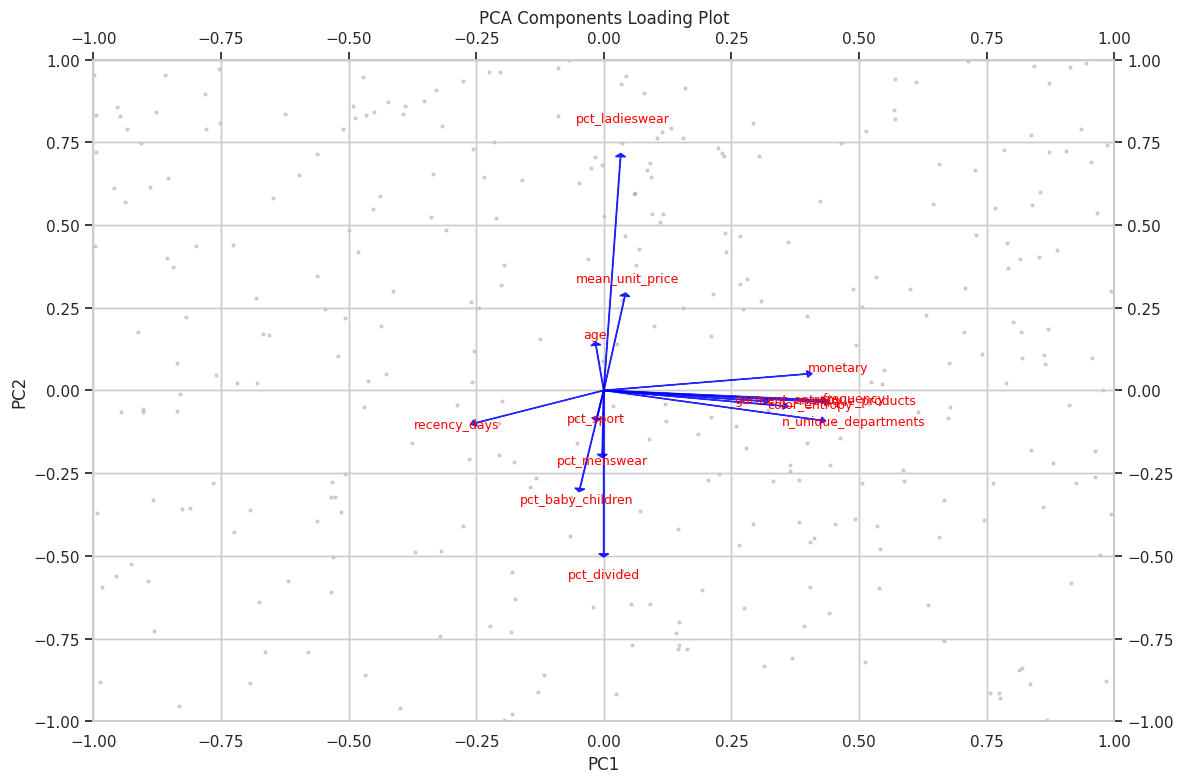

In [30]:
#Components loading:
components_loading = pd.DataFrame(
    pca.components_,
    columns= X.columns,
    index = [f'PC{i+1}' for i in range(len(X.columns))]
)
components_loading.head(5)

#Plot for components loading:
fig, ax1 = plt.subplots(figsize=(12,8))

#Set limit for data range:
ax1.set_xlim(-1,1)
ax1.set_ylim(-1,1)

sample_idx= np.random.choice(len(X_pca), 2000, replace= False)

ax1.scatter(X_pca[sample_idx,0], X_pca[sample_idx,1], alpha=0.3, color= 'gray', s=4)

#Create second axis:
ax2 = ax1.twinx().twiny()

#Loading scale for ax2:
ax2.set_xlim(-1,1)
ax2.set_ylim(-1,1)

#Arrow for loading components:
for i, col in enumerate(X.columns):
  comp = pca.components_[:,i]
  ax2.arrow(0,0,
            comp[0],
            comp[1],
            head_width= 0.02, head_length=0.01,
            color= 'blue', alpha = 0.8)
  ax2.text(
      comp[0]*1.15,
      comp[1]*1.15,
      col, fontsize= 9, color= 'red', ha= 'center')


ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_title('PCA Components Loading Plot')
plt.tight_layout()
plt.show()


PCA loadings describe how each original features contributes to the principle components. By looking theseloadings, we can identify the meaning of each component that associate with customer behavior.

The first principle is dominated by features like purchase frequency, total spending, and product variety. Those represent the overall customer engagement. Customers with higher values tend to purchase more freuqently and spend more. The second principle is influenced by category composition variables, such as proportion of purchase across different products. This component captures the differences in preference, it also distinguishes customers that tend to buy different products a lot.

Overall, this loading shows how PCA separate customers' behaviors into independent dimension by showing how much they spend and what they prefer to buy.

### PCA: Customers in the First Two Components



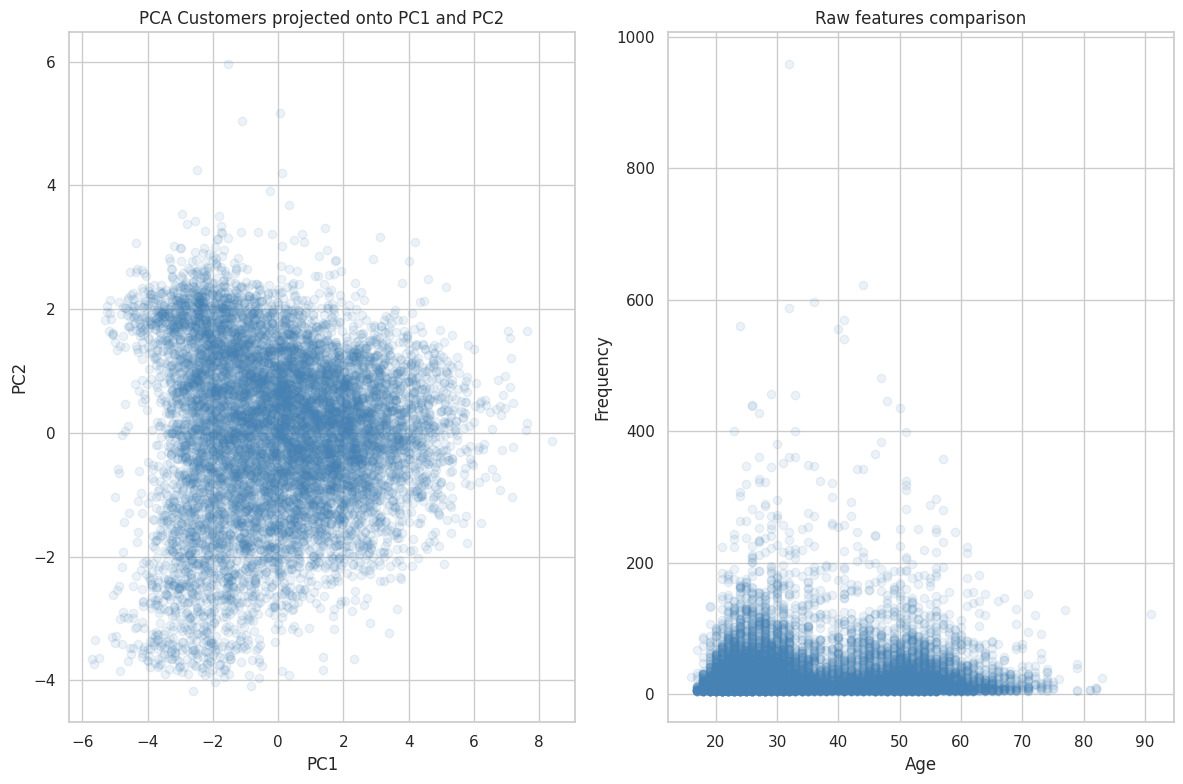

In [31]:
#Plot the first two components:
fig, ax = plt.subplots(1,2,figsize =(12,8))
ax[0].scatter(X_pca[:,0], X_pca[:,1], color='steelblue', alpha=0.1)
ax[0].set_xlabel('PC1')
ax[0].set_ylabel('PC2')
ax[0].set_title('PCA Customers projected onto PC1 and PC2')

#Comparison with raw features:
ax[1].scatter(features['age'], features['frequency'],color='steelblue', alpha=0.1)
ax[1].set_xlabel('Age')
ax[1].set_ylabel('Frequency')
ax[1].set_title('Raw features comparison')
plt.tight_layout()
plt.show()

Projecting customers onto the first two principal components creates a two-dimensional view of the dataset. Each point represents a customer, with its position reflecting that customer's overall behavioral profile.

The PCA projection shows that customers are distributed continuously rather than in clearly separated clusters. Customer behavior varies along smooth gradients rather than falling into discrete segments. The horizontal axis (PC1) represents a spectrum of engagement levels, while the vertical axis (PC2) captures variation in product preference.

Compared to the raw feature plot of age versus frequency, the PCA projection reveals structure that the raw features cannot show on their own. The raw plot shows mostly a concentration of customers at low frequency values across the age range, capturing only one dimension of variation at a time. The PCA projection, by contrast, spreads customers along two informative axes simultaneously, demonstrating that PCA reduces redundancy and provides a more useful view for downstream analysis.


### SVD and Matrix Completion




 Latent variance explained:  [8.32630952e-01 5.30441149e-02 4.02497161e-02 3.56823075e-02
 2.11897445e-02 8.09095814e-03 4.48845034e-03 3.26122873e-03
 1.14066902e-03 2.00666610e-04 9.37658137e-06 7.55293256e-06
 2.18832587e-06 9.37635993e-07 7.41091181e-07 1.04461286e-07
 1.04459922e-07 1.04336437e-07 8.23486981e-08]

 Latent factor loadings for Product Categories:


product_group_name,Accessories,Bags,Cosmetic,Fun,Furniture,Garment Full body,Garment Lower body,Garment Upper body,Garment and Shoe care,Interior textile,Items,Nightwear,Shoes,Socks & Tights,Stationery,Swimwear,Underwear,Underwear/nightwear,Unknown
latent_1,-0.090290,-0.000395,-3.367891e-05,-0.000002,-2.386285e-05,-0.239003,-0.454485,-0.829896,-0.000056,-0.000004,-0.000179,-0.021145,-0.053789,-0.032362,-0.000042,-0.133236,-0.131428,-5.561989e-07,-0.005383
latent_2,0.016225,-0.000058,-1.095038e-05,-0.000004,-1.150550e-05,0.772111,0.375295,-0.471927,-0.000047,0.000017,-0.000069,0.005227,0.029303,0.004573,-0.000005,0.187524,0.062816,-2.114456e-06,0.001248
latent_3,-0.023381,-0.000014,5.092600e-05,0.000004,-4.092193e-07,-0.564500,0.765431,-0.280277,-0.000047,0.000039,0.000099,0.005119,-0.014576,0.008717,0.000029,0.052368,0.115223,4.090072e-07,0.004550
latent_4,-0.086439,-0.000195,7.250891e-05,0.000007,8.240181e-05,0.140864,0.252995,0.044593,0.000027,0.000013,-0.000555,-0.024354,-0.010645,-0.045336,-0.000093,-0.781987,-0.540693,-7.358556e-06,-0.008664
latent_5,0.053554,0.000680,-7.092984e-07,-0.000004,7.661710e-06,0.068735,-0.045733,-0.040884,0.000058,-0.000010,0.000299,0.032448,0.014478,0.071995,0.000225,-0.574493,0.807420,1.205875e-05,0.015126


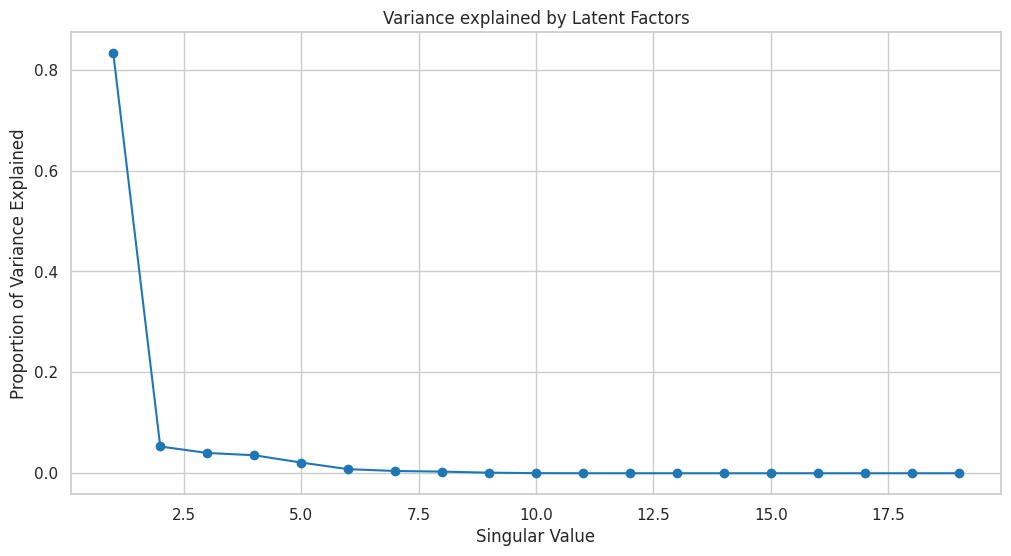


 Iteration count: 228

 Relative improvement: 9.90961414855265e-08

 MSE: 5.1644601216841775

 Test MSE:  57.54239227988129

 Baseline MSE:  43.467824954582326


In [32]:
from numpy.linalg import svd

#Convert data to matrix:
X_matrix= customer_category_matrix.values

#SVD:
U, S, V = np.linalg.svd(X_matrix, full_matrices= False)

#Variance explained by each singular value:
var_explained = (S**2) / np.sum(S**2)
print('\n Latent variance explained: ', var_explained)


#Display first few rows of V (laten factor loadings)
print('\n Latent factor loadings for Product Categories:')

display(pd.DataFrame(
    V[:5],
    columns = customer_category_matrix.columns,
    index = [f'latent_{i+1}' for i in range(5)]
))


#Plot singular value:
fig, ax = plt.subplots(figsize = (12,6))
ax.plot(np.arange(1, len(S)+1), var_explained, marker ='o')
ax.set_xlabel('Singular Value')
ax.set_ylabel('Proportion of Variance Explained')
ax.set_title('Variance explained by Latent Factors')
plt.show()

#Retain top latent factors for clustering:
n_latent= 5
customer_latent= U[:, :n_latent] * S[:n_latent]
customer_latent= pd.DataFrame(
    customer_latent,
    index= customer_category_matrix.index,
    columns= [f'latent_{i+1}' for i in range(n_latent)]
)

#Randomly mask 10% of entries to simulate missing data:
np.random.seed(42)
X_na= X_matrix.astype(float).copy()
mask = np.random.rand(*X_na.shape)<0.1
X_na[mask]= np.nan

#Initialize missing entries with column means:
X_hat = X_na.copy()
X_bar= np.nanmean(X_na,axis=0)
ismiss= np.isnan(X_hat)
X_hat[ismiss]= X_bar[np.where(ismiss)[1]]

#Set up convergence tracking:
threshold = 1e-7
relative_err= 1
iter_count = 0
mssold= np.nanmean(X_hat[~ismiss]**2)
mss0 = np.nanmean(X_na[~ismiss]**2)

#Low rank approximation:
def low_rank(X, M=1):
  u,s,v = np.linalg.svd(X, full_matrices= False)
  return u[:, :M] @ np.diag (s[:M]) @ v[:M, :]

#Iterate until  relative improvement below threshold:
while relative_err > threshold:
  iter_count +=1
  X_app= low_rank(X_hat, M=2)
  X_hat[ismiss]= X_app[ismiss]
  mss= np.nanmean(((X_na - X_app)[~ismiss])**2)
  relative_err = (mssold - mss)/mss0
  mssold = mss

print(f'\n Iteration count: {iter_count}')
print(f'\n Relative improvement: {relative_err}')
print(f'\n MSE: {mss}')

#Evaluate matrix completion performance:
test_mse = np.mean((X_app[mask] - X_matrix[mask])**2)
baseline_mse = np.mean((X_bar[np.where(mask)[1]]- X_matrix[mask])**2)
print('\n Test MSE: ', test_mse)
print('\n Baseline MSE: ', baseline_mse)


Singular Value Decomposition (SVD) is applied to the customer-by-category purchase matrix to reveal latent patterns in purchasing behavior. The matrix records how often each customer buys items from each of the 19 product categories. SVD decomposes this matrix into a set of latent factors that capture the dominant relationships between customers and product categories. The first five rows of V* (displayed above) show what each latent factor represents in terms of categories, with dominant categories per factor indicating, for example, a Ladieswear-leaning factor versus factors that contrast against other index groups.

To demonstrate matrix completion, we randomly mask 10% of observed entries (treating them as missing) and run the iterative ISLR2 algorithm: initialize the missing entries with column means, fit a low-rank SVD approximation to the current matrix, replace the missing entries with the approximation's predictions, and repeat until the relative improvement falls below a threshold.

Performance is evaluated by comparing the test mean squared error on the masked entries against a simple column-mean baseline. In our run, the test MSE was actually higher than the baseline MSE, meaning the rank-2 approximation does not generalize better than predicting each category's average. This likely reflects the matrix's extreme sparsity (about 76% zeros), which gives a low-rank model limited signal to learn from. A higher-rank approximation, a smaller masking fraction, or a different completion algorithm might improve performance. The conclusion is that while SVD on this matrix successfully captures the dominant patterns for interpretation and downstream clustering, those patterns are not strong enough at rank 2 to support reliable cell-by-cell prediction.

## Clustering

After completing the PCA, SVD, and matrix-completion analyses, we next use clustering to identify groups of customers with similar shopping behavior. We use two clustering approaches: k-means clustering and hierarchical clustering. K-means provides a direct partition of customers into a chosen number of clusters, while hierarchical clustering builds a tree of customer similarity and allows us to compare different linkage methods. Using both methods allows us to check whether the same broad customer groups appear across different clustering approaches.

### K-means
 We first apply k-means clustering to the final 14-feature customer dataset, using the same preprocessed and standardized matrix created in the PCA section. In that preprocessing step, missing age values were replaced with the median, right-skewed count and spending variables were log-transformed, and all features were standardized. We then compare different values of K using the WCSS plot, silhouette scores, and silhouette coefficient plots.

In [33]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.decomposition import PCA

In [34]:
wcss = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state= 2, n_init=20)
    labels = kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

kmeans_tuning = pd.DataFrame({
    "K": list(K_range),
    "WCSS": wcss,
    "Silhouette Score": silhouette_scores})

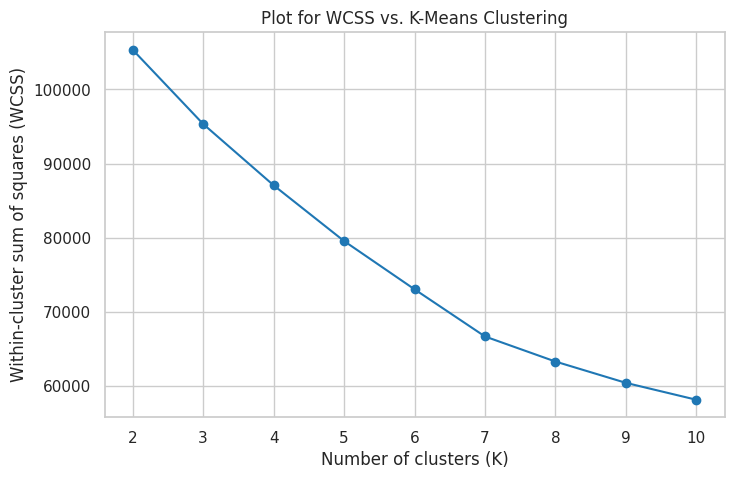

In [35]:
# plot WCSS vs. K values
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(kmeans_tuning["K"], kmeans_tuning["WCSS"], marker="o")
ax.set_xlabel("Number of clusters (K)")
ax.set_ylabel("Within-cluster sum of squares (WCSS)")
ax.set_title("Plot for WCSS vs. K-Means Clustering")
ax.grid(True)
plt.show()

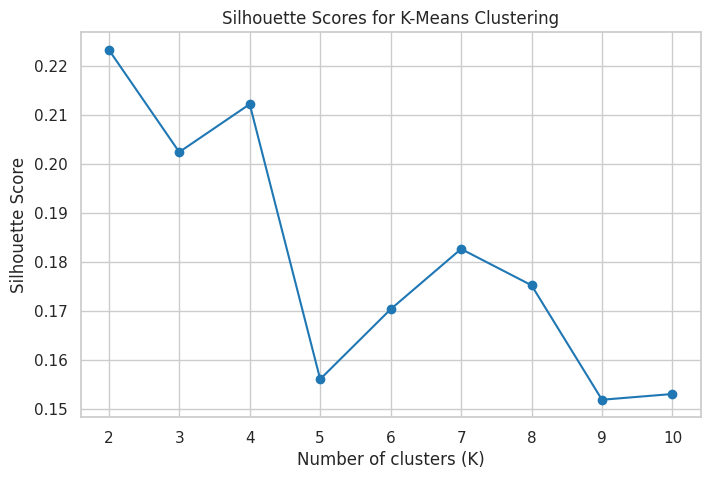

In [36]:
# Silhouette score plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(kmeans_tuning["K"], kmeans_tuning["Silhouette Score"], marker="o")
ax.set_xlabel("Number of clusters (K)")
ax.set_ylabel("Silhouette Score")
ax.set_title("Silhouette Scores for K-Means Clustering")
ax.grid(True)
plt.show()

To choose the number of clusters for k-means, we compared the within-cluster sum of squares (WCSS) and silhouette scores for K = 2 through K = 10. The WCSS plot above did not show a single obvious elbow point; instead, the WCSS values decreased steadily as K increased. This is expected because adding more clusters will always reduce within-cluster variantion. The silhouette score was highest for K = 2, but this solution might be quite broad for a sample of 10,000 customers and would likely produce overly general customer segments. Among the more detailed solutions, K = 4 and K = 7 are both competitive. Although the silhouette score for K = 7 is relatively lower than that of K = 4, a larger K value may capture additional meaninful structure in the data and useful for separating smaller specialist customer groups. Hence, we further compared silhouette coefficient analysis plots for K = 4 and K = 7 before choosing the final segmentation.

In [37]:
#Plot Silhouette analysis for K-means cluster

def silhouette_analysis_plot(X_cluster, n_clusters, random_state=42, n_init=20):
    # Fit k-means
    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=random_state,
        n_init=n_init)

    cluster_labels = kmeans.fit_predict(X_cluster)

    # Compute silhouette values
    silhouette_avg = silhouette_score(X_cluster, cluster_labels)
    sample_silhouette_values = silhouette_samples(X_cluster, cluster_labels)

    # Create plot
    fig, ax = plt.subplots(figsize=(8, 6))

    ax.set_xlim([-0.1, 1])
    ax.set_ylim([0, len(X_cluster) + (n_clusters + 1) * 10])

    y_lower = 10
    colors = plt.cm.viridis(np.linspace(0, 1, n_clusters))

    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = colors[i]

        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.8)

        ax.text(
            -0.05,
            y_lower + 0.5 * size_cluster_i,
            str(i + 1))

        y_lower = y_upper + 10

    # Average silhouette score line
    ax.axvline(
        x=silhouette_avg,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Average silhouette = {silhouette_avg:.3f}")

    ax.set_title(f"Silhouette Plot for K-Means Clustering, K = {n_clusters}")
    ax.set_xlabel("Silhouette coefficient values")
    ax.set_ylabel("Cluster label")
    ax.legend()

    plt.tight_layout()
    plt.show()

    print(f"K = {n_clusters}")
    print(f"Average silhouette score = {silhouette_avg:.4f}")

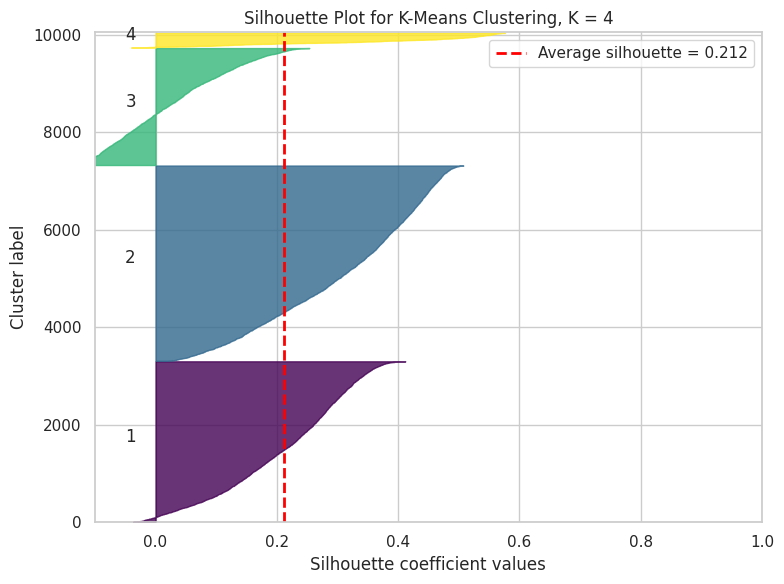

K = 4
Average silhouette score = 0.2118


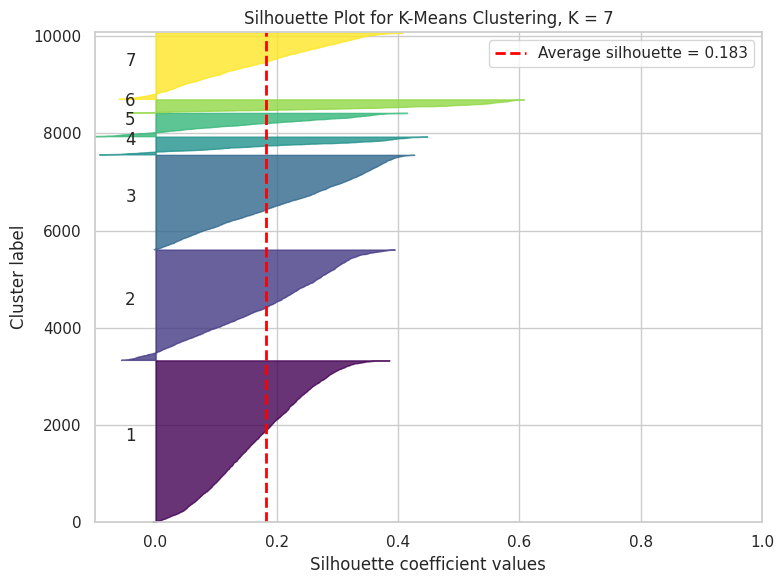

K = 7
Average silhouette score = 0.1828


In [38]:
#Compare Silhouette plot for K = 4 vs. K = 7
silhouette_analysis_plot(X_scaled, n_clusters=4)
silhouette_analysis_plot(X_scaled, n_clusters=7)

Based on the filhouette coefficient analysis plots above, neither soluytion shows perfectly seperated clusters. For K = 4, the average silhouette score is higher (around 0.212) and most observations have positive silhouette values. However, some clusters still contain observations near zero, indicating overlap between customer segments. For K = 7, the average silhouette score decreased to around 0.183, and several clusters become smaller with more observations near zero. This suggests that the seven-cluster solution provides more detailed segmentation but weaker separation. Therefore, to generate a more stable and parsimonious clustering solution, K = 4 is selected as the final solution.

In [39]:
#Final k_means model with K = 4
FINAL_K = 4
kmeans_final = KMeans(
    n_clusters=FINAL_K,
    random_state=2,
    n_init=20)
kmeans_labels = kmeans_final.fit_predict(X_scaled)
print(f"Final number of clusters: {FINAL_K}")
print(f"Final WCSS: {kmeans_final.inertia_:.2f}")
print(f"Final silhouette score: {silhouette_score(X_scaled, kmeans_labels):.4f}")

Final number of clusters: 4
Final WCSS: 87072.28
Final silhouette score: 0.2122


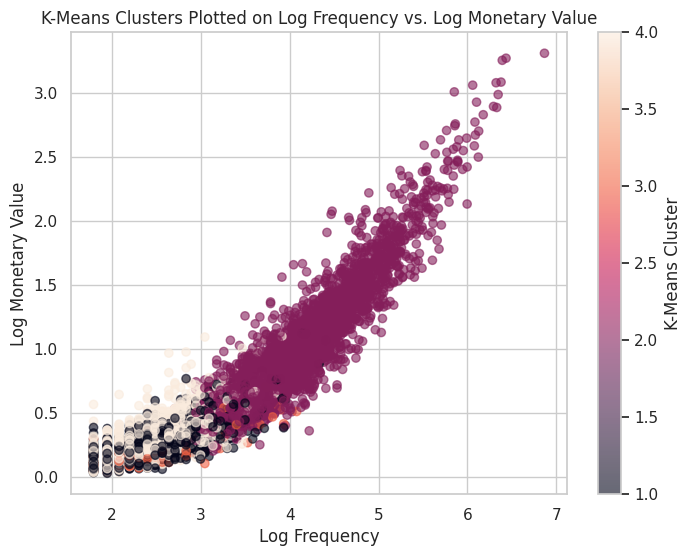

In [40]:
# Plot k-means clusters on two original features
original_plot_df = X.copy()
original_plot_df["kmeans_cluster"] = kmeans_labels + 1

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    original_plot_df["frequency"],
    original_plot_df["monetary"],
    c=original_plot_df["kmeans_cluster"],
    alpha=0.6)

ax.set_xlabel("Log Frequency")
ax.set_ylabel("Log Monetary Value")
ax.set_title("K-Means Clusters Plotted on Log Frequency vs. Log Monetary Value")
plt.colorbar(scatter, ax=ax, label="K-Means Cluster")
plt.show()

To visualize the clustering results, we first plotted the k-means clusters using log frequency and log monetary value. The plot shows a very strong positive relationship between purchase frequency and total monetary value, as customers who buy more often also tend to spend more overall. The clusters are partly separated along this frequency/spending direction.  In particular, one cluster captures the higher-frequency and higher-spending customers, while the other clusters are concentrated among lower- to moderate-frequency customers. However, there is still overlap among the lower-frequency groups, suggesting that the k-means solution is not based only on frequency and spending.

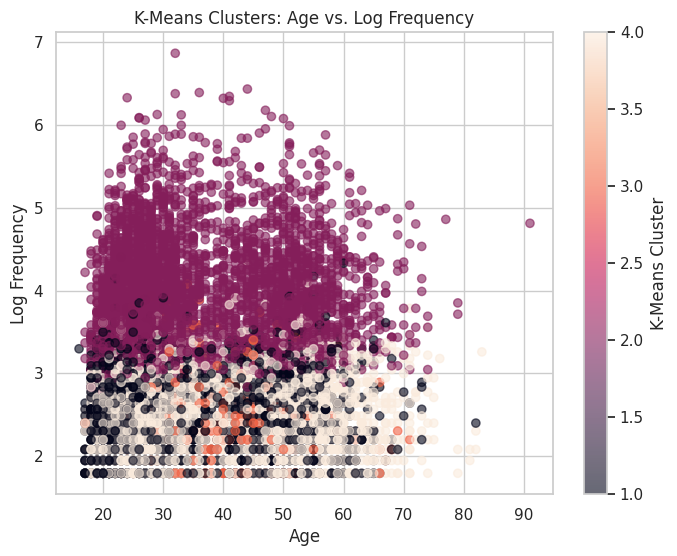

In [41]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    original_plot_df["age"],
    original_plot_df["frequency"],
    c=original_plot_df["kmeans_cluster"],
    alpha=0.6)

ax.set_xlabel("Age")
ax.set_ylabel("Log Frequency")
ax.set_title("K-Means Clusters: Age vs. Log Frequency")
plt.colorbar(scatter, ax=ax, label="K-Means Cluster")
plt.show()

The age versus log frequency plot shows that the clusters are not primarily separated by age. Most clusters contain customers across a wide age range, and there is substantial overlap.  The clearer separation is again along frequency: one cluster contains the more active shoppers, while the other clusters are concentrated at lower or moderate purchase frequencies. This suggests that customer engagement is more important than age in defining the k-means segments. Age may still help describe some differences across clusters, but it does not appear to be the main driver of the segmentation.

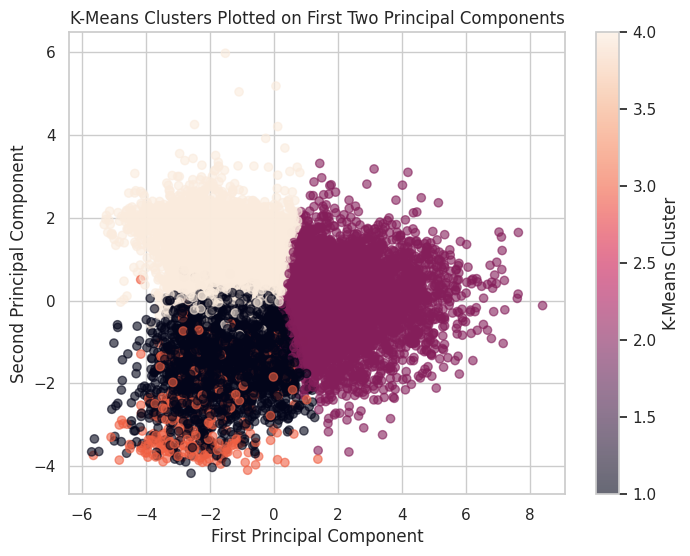

In [42]:
# Plot final k-means clusters on the first two principal components
pca_plot_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "kmeans_cluster": kmeans_labels + 1})

fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
    pca_plot_df["PC1"],
    pca_plot_df["PC2"],
    c=pca_plot_df["kmeans_cluster"],
    alpha=0.6)

ax.set_xlabel("First Principal Component")
ax.set_ylabel("Second Principal Component")
ax.set_title("K-Means Clusters Plotted on First Two Principal Components")
plt.colorbar(scatter, ax=ax, label="K-Means Cluster")
plt.show()

When plotted on the first two principal components, the k-means clusters are more visibly than in the original-feature plots. This is especially clear for the large cluster on the right side of the PCA plot, which is separated from the other clusters along the first principal component. The remaining clusters are located more toward the left side of the plot and are separated more clearly along the second principal component. However, there is still some overlap near the center of the PCA plot, so the customer segments should be interpreted as useful behavioral groupings rather than perfectly distinct natural categories.

### Hierarchical Clustering

Next, we apply hierarchical clustering to the same preprocessed 14-feature customer matrix. In this project, we focus on complete and Ward linkage. Single linkage is not adopted because it often creates a chaining effect where clusters are formed by gradually linking nearby observatiosn rather than creating clearly separated groups. Average linkage is more balanced than single linkage, but it does not enforce compactness as strongly as complete or Ward. Ward linkage is more appropriate for standardizded numerical data, and complete linkage is included as a comparison because it also tends to form compact clusters. We then cut dendrograms of each linkage into four clusters to match the final K=4 k-means solution, allowing us to compare whether the two clustering approaches identify similar customer segments.

In [43]:
!pip install ISLP --quiet
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, cut_tree
from ISLP.cluster import compute_linkage

X_scaled_df = pd.DataFrame(
    X_scaled,
    index=features.index,
    columns=features.columns)

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 7.7 MB/s eta 0:00:00


In [44]:
#Using complete linkage for hierarchical clustering
HClust = AgglomerativeClustering
hc_comp = HClust(distance_threshold=0,
                 n_clusters=None,
                 linkage='complete',
                 metric = 'euclidean')
hc_comp.fit(X_scaled_df)

AgglomerativeClustering(distance_threshold=0, linkage='complete',
                        n_clusters=None)

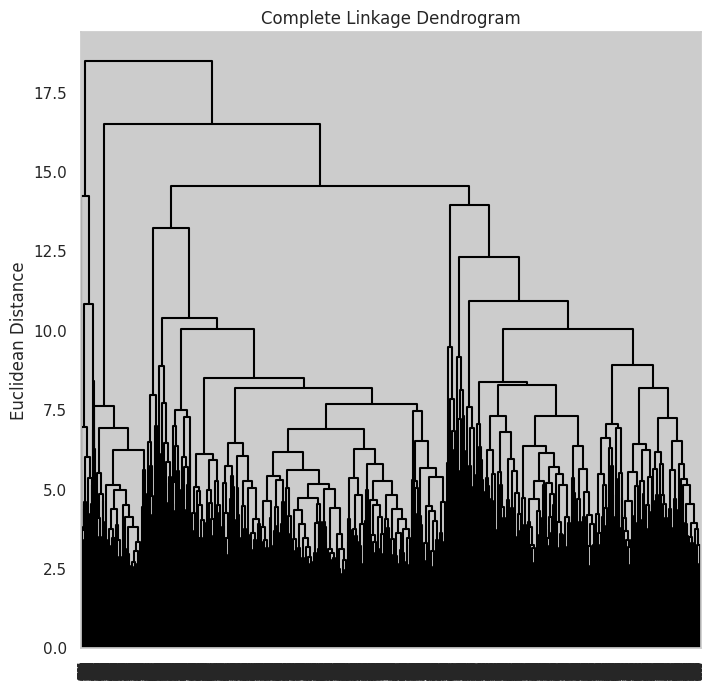

In [45]:
#Plot dendrogram for complete-linkage hierarchical clustering
cargs = {'color_threshold':-np.inf,
         'above_threshold_color':'black'}

linkage_comp = compute_linkage(hc_comp)

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
dendrogram(linkage_comp,
           ax=ax,
           **cargs);
ax.set_title("Complete Linkage Dendrogram")
ax.set_ylabel("Euclidean Distance")
plt.show()

In [46]:
# Cut the complete-linkage dendrogram into 4 clusters
hc_comp_labels = cut_tree(linkage_comp, n_clusters= 4).reshape(-1) + 1

# Check labels
np.unique(hc_comp_labels, return_counts=True)

(array([1, 2, 3, 4]), array([4084, 4834,  867,  215]))

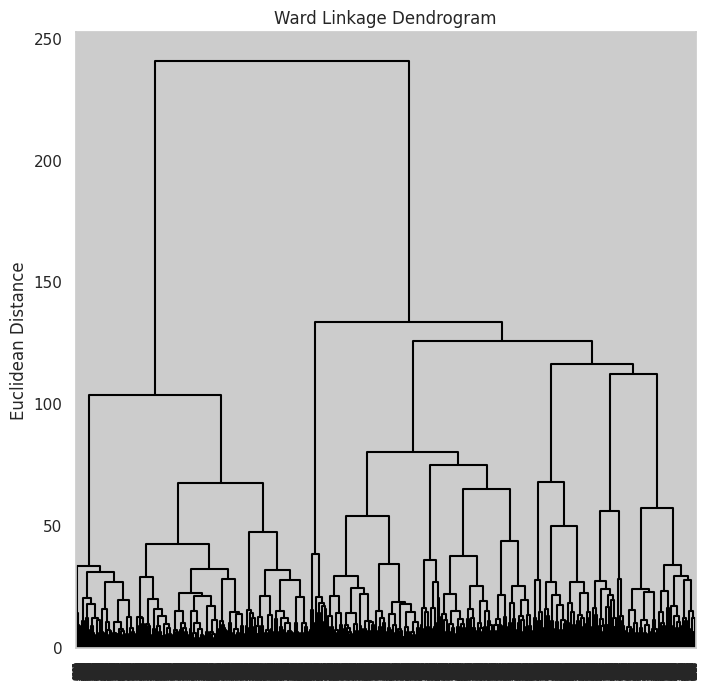

In [47]:
#Using ward linkage for hierarchical clustering
hc_ward = HClust(distance_threshold=0,
                   n_clusters=None,
                   linkage='ward',
                   metric = 'euclidean')
hc_ward.fit(X_scaled_df)

linkage_ward = compute_linkage(hc_ward)

#Plot dendrogram for Ward-linkage hierarchical clustering
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
dendrogram(linkage_ward,
           ax=ax,
           **cargs);
ax.set_title("Ward Linkage Dendrogram")
ax.set_ylabel("Euclidean Distance")
plt.show()

In [48]:
# Cut the ward-linkage dendrogram into 4 clusters
hc_ward_labels = cut_tree(linkage_ward, n_clusters= 4).reshape(-1) + 1

# Check labels
np.unique(hc_ward_labels, return_counts=True)

(array([1, 2, 3, 4]), array([3352, 2602, 3766,  280]))

In [49]:
complete_silhouette = silhouette_score(X_scaled_df, hc_comp_labels)
ward_silhouette = silhouette_score(X_scaled_df, hc_ward_labels)
kmeans_silhouette = silhouette_score(X_scaled_df, kmeans_labels)

print(f"Complete linkage silhouette score: {complete_silhouette:.4f}")
print(f"Ward linkage silhouette score: {ward_silhouette:.4f}")
print(f"K-means silhouette score: {kmeans_silhouette:.4f}")

Complete linkage silhouette score: 0.0953
Ward linkage silhouette score: 0.1623
K-means silhouette score: 0.2122


We compared complete and Ward linkage after cutting each dendrogram into four clusters. Complete linkage produced cluster sizes of 4,084, 4,834, 867, and 215, while Ward linkage produced cluster sizes of 3,352, 2,602, 3,766, and 280. Both methods created one relatively small cluster, suggesting that the data contain some smaller specialist segments. However, Ward linkage produced a more balanced solution overall. We also compared silhouette scores: complete linkage had a silhouette score of 0.0953, while Ward linkage improved to 0.1623. The k-means solution had the highest silhouette score, 0.2122. This suggests that k-means produced the strongest separation among the three methods, but among the hierarchical methods, Ward linkage was preferable to complete linkage. Therefore, we used Ward linkage as the primary hierarchical clustering comparison.

### Cluster Membership and Interpretation

After fitting the k-means and hierarchical clustering models, we next interpret the resulting customer segments using the original feature values. Because clustering only assigns numerical labels, the labels themselves do not have meaning until we examine the characteristics of customers in each group. To do this, we calculate the mean of each original feature within each cluster.

We first interpret the k-means solution, since it produced the strongest silhouette score and serves as our primary segmentation model.

In [50]:
# Add final k-means labels to the original features dataframe
features_kmeans = features.copy()
features_kmeans["kmeans_cluster"] = kmeans_labels + 1

# Check cluster sizes
cluster_sizes = features_kmeans["kmeans_cluster"].value_counts().sort_index()
cluster_sizes


,count
kmeans_cluster,
1,2372
2,4014
3,302
4,3312


In [51]:
# Mean of each original feature by cluster
cluster_summary = features_kmeans.groupby("kmeans_cluster").mean(numeric_only=True)

cluster_summary.round(2)

,recency_days,frequency,monetary,n_unique_products,n_unique_departments,color_entropy,garment_entropy,mean_unit_price,age,pct_baby_children,pct_divided,pct_ladieswear,pct_menswear,pct_sport
kmeans_cluster,,,,,,,,,,,,,,
1,219.50,13.10,0.33,11.45,7.26,2.12,1.43,0.03,33.71,0.02,0.43,0.37,0.11,0.08
2,71.81,66.09,1.87,56.11,22.09,3.15,2.08,0.03,35.65,0.03,0.21,0.66,0.06,0.04
3,532.45,11.90,0.24,10.46,6.37,2.25,1.42,0.02,40.58,0.69,0.07,0.17,0.04,0.02
4,227.59,11.86,0.33,10.24,5.93,2.06,1.34,0.03,37.95,0.01,0.10,0.84,0.02,0.02


The cluster summary table above shows that the four k-means clusters differ along both engagement and product-composition dimensions. Cluster 2 shows a distinct purchase pattern from other three clusters, which features the most active and high-value customer group (e.g., lowest recency, highest frequency, highest monetary value) with greatest product and department variety. This groups is also ladieswear-oriented. In contrast, Cluster 1, 3, and 4 have much lower frequency, spending and variety but they differ in what they buy. Cluster 1 has the highest share of Divided (H&M's younger fashion line) purchase; Cluster 3 is strongly baby-children focused and highest recency, suggesting an inactive baby/children segment; Clustrer 4 is also highly ladieswear-focused but has much lower engagement than Cluster 2, suggesting an occasional/low engagement ladieswear segment.

The PCA loading plot from the previous section shows that PC1 mainly reflects engagement and variety, including frequency, monetary value, unique products, unique departments, and entropy. This explains why Cluster 2 appears on the right side of the PCA plot: it contains the most active and highest-spending customers. PC2 is more related to product composition, separating customers with higher Ladieswear shares from those with higher Divided, Baby/Children, or Menswear shares.

These clustering results are also consistent with the earlier EDA on product-composition features. In the EDA, most customers were primarily Ladieswear shoppers, while smaller groups specialized in Divided, Menswear, Baby/Children, or Sport. This suggested a two-layer segmentation structure: product-composition features would identify specialist groups, while behavioral features would further separate customers by engagement, spending, and variety.
The K-measn results support this pattern by separating one high-value active segment from several lower-engagement segments that differ mainly by product preference.

We then interpret the Ward hierarchical clusters and compare them with the k-means clusters. This helps assess whether the same broad customer segments appear under a different clustering method.

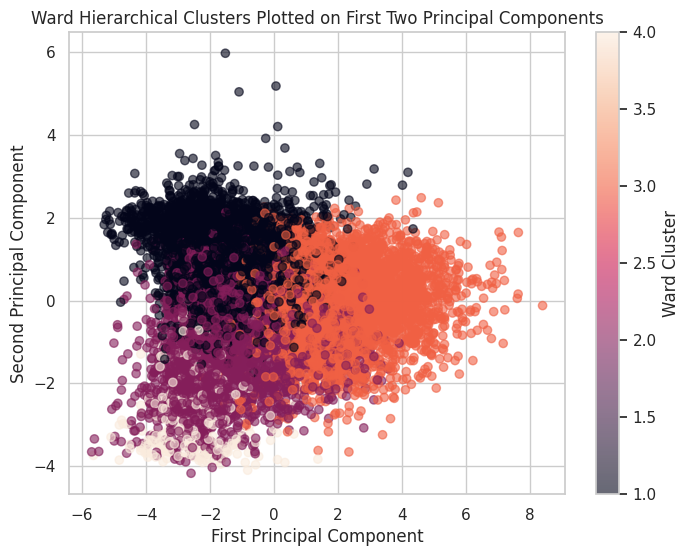

In [52]:
# Plot Ward hierarchical clusters on first two PCA components
pca_ward_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "ward_cluster": hc_ward_labels}, index=features.index)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    pca_ward_df["PC1"],
    pca_ward_df["PC2"],
    c=pca_ward_df["ward_cluster"],
    alpha=0.6)

ax.set_xlabel("First Principal Component")
ax.set_ylabel("Second Principal Component")
ax.set_title("Ward Hierarchical Clusters Plotted on First Two Principal Components")
plt.colorbar(scatter, ax=ax, label="Ward Cluster")

plt.show()

In [53]:
features_hc_ward = features.copy()
features_hc_ward["hc_ward_cluster"] = hc_ward_labels

hc_ward_summary = (
    features_hc_ward
    .groupby("hc_ward_cluster")
    .mean(numeric_only=True))

hc_ward_summary.insert(
    0,
    "n_customers",
    features_hc_ward["hc_ward_cluster"].value_counts().sort_index())

hc_ward_summary.round(2)

,n_customers,recency_days,frequency,monetary,n_unique_products,n_unique_departments,color_entropy,garment_entropy,mean_unit_price,age,pct_baby_children,pct_divided,pct_ladieswear,pct_menswear,pct_sport
hc_ward_cluster,,,,,,,,,,,,,,,
1,3352,219.70,13.35,0.39,11.54,6.64,2.09,1.41,0.03,36.81,0.01,0.13,0.83,0.01,0.01
2,2602,209.47,15.64,0.40,13.67,8.08,2.21,1.47,0.03,33.99,0.02,0.34,0.41,0.15,0.09
3,3766,75.34,66.56,1.88,56.41,21.91,3.14,2.04,0.03,36.63,0.04,0.23,0.65,0.04,0.04
4,280,565.28,11.23,0.22,9.83,5.93,2.25,1.38,0.02,39.94,0.69,0.09,0.16,0.03,0.02


In [54]:
#compare Ward hierarchical clustering to k-means
features_compare = features.copy()
features_compare["kmeans_cluster"] = kmeans_labels + 1
features_compare["hc_ward_cluster"] = hc_ward_labels
pd.crosstab(
    features_compare["hc_ward_cluster"],
    features_compare["kmeans_cluster"],
    rownames=["Ward hierarchical cluster"],
    colnames=["K-means cluster"])

K-means cluster,1,2,3,4
Ward hierarchical cluster,,,,
1,338,354,2,2658
2,1825,324,7,446
3,190,3335,36,205
4,19,1,257,3


Ward hierarchical clustering produced four customer segments that were broadly similar to the k-means solution. Ward Cluster 3 corresponds to the high-value active shopper segment (K-means Cluster 2), with the lowest recency, highest frequency, highest monetary value, and greatest product variety. Ward Cluster 4 corresponds to a small inactive Baby/Children-focused segment (K-means Cluster 3), with very high recency and a large share of Baby/Children purchases. Ward Cluster 1 captures low-engagement Ladieswear-focused shoppers (similar to K-measn Cluster 1), while Ward Cluster 2 represents a lower-engagement mixed segment with higher Divided, Menswear, and Sport purchases.

When plotted on the first two principal components, the Ward clusters show a similar structure to k-means: the high-engagement cluster is separated on the right side of PC1, while the lower-engagement clusters are located more on the left and differ mainly by product composition. However, the Ward clusters overlap more than the k-means clusters, which is consistent with the lower silhouette score for Ward linkage. Overall, hierarchical clustering supports the same broad segmentation found by k-means, although k-means produced slightly clearer separation.

To complement the main clustering analysis, we also ran k-means on the five SVD latent factors from the customer-by-category matrix. This provides a product-preference-based clustering view and helps evaluate whether the category-purchase structure supports the same customer segments found using the 14 engineered features.

In [55]:
# Wrap the existing SVD results into a DataFrame
customer_latent = pd.DataFrame(
    customer_latent,
    index=customer_category_matrix.index,
    columns=[f'latent_{i+1}' for i in range(n_latent)])

# Scale the latent factors for clustering
customer_latent_scaled = StandardScaler().fit_transform(customer_latent)

# K-means on SVD latent factors
kmeans_latent = KMeans(
    n_clusters=4,
    random_state=2,
    n_init=20)

latent_labels = kmeans_latent.fit_predict(customer_latent_scaled)

print("K-means on SVD latent factors")
print(f"Silhouette score: {silhouette_score(customer_latent_scaled, latent_labels):.4f}")

print("\nCluster sizes:")
print(pd.Series(latent_labels + 1).value_counts().sort_index())


K-means on SVD latent factors
Silhouette score: 0.4833

Cluster sizes:
1     629
2     705
3     451
4    8215
Name: count, dtype: int64


In [56]:
#compare latene-factor clusters with main k-means clusters
latent_compare = pd.DataFrame({
    "main_kmeans_cluster": kmeans_labels + 1,
    "latent_kmeans_cluster": latent_labels + 1}, index=features.index)

pd.crosstab(
    latent_compare["latent_kmeans_cluster"],
    latent_compare["main_kmeans_cluster"],
    rownames=["SVD latent-factor cluster"],
    colnames=["Main 14-feature k-means cluster"])

Main 14-feature k-means cluster,1,2,3,4
SVD latent-factor cluster,,,,
1,12,454,0,163
2,23,588,2,92
3,1,450,0,0
4,2336,2522,300,3057


The SVD latent factors summarize lower-dimensional product-category purchase patterns, so the clustering on SVD latent factors focuses more directly on what customers buy rather than on the full set of behavioral and demographic features. The comparison table shows that the SVD latent-factor clusters do not map perfectly onto the main 14-feature k-means clusters. The latent-factor clusters mainly separate customers by product-category purchase patterns, especially different apparel categories (such as upper-body garments, lower-body garments, full-body garments, underwear, swimwear, and accessories). Overall, this analysis supports the idea that product preference is an important dimension of customer segmentation, but the main 14-feature k-means solution remains more comprehensive and interpretable because it combines product composition with engagement and demographic information.

We also used the validation labels as an external check, as they provide additional information for evaluating whether the segments differ in meaningful ways. Specifically, we compare the clusters by age and club member status to see whether the customer groups identified by k-means and Ward hierarchical clustering also show demographic or membership differences.

In [57]:
#External validation: club member status by k-means cluster
features_kmeans_v = features_kmeans.join(
    validation_labels[["club_member_status"]],
    how="left")

pd.crosstab(
    features_kmeans_v["kmeans_cluster"],
    features_kmeans_v["club_member_status"],
    normalize="index").round(3)

club_member_status,ACTIVE,LEFT CLUB,PRE-CREATE
kmeans_cluster,,,
1,0.940,0.0,0.059
2,0.989,0.0,0.011
3,0.848,0.0,0.152
4,0.940,0.0,0.060


In [58]:
#External validation: club member status by Ward hierarchical cluster
features_ward_v = features_hc_ward.join(
    validation_labels[["club_member_status"]],
    how="left")

pd.crosstab(
    features_ward_v["hc_ward_cluster"],
    features_ward_v["club_member_status"],
    normalize="index").round(3)

club_member_status,ACTIVE,LEFT CLUB,PRE-CREATE
hc_ward_cluster,,,
1,0.941,0.001,0.059
2,0.945,0.000,0.055
3,0.988,0.000,0.012
4,0.844,0.000,0.156


Club member status provides a useful external check because it was not used in the clustering model. Although most sampled customers are ACTIVE members, the cluster-level proportions still show meaningful differences. In both k-means and Ward clustering, the high-engagement cluster has the highest ACTIVE share (i.e.,98.8%–98.9%), while the inactive Baby/Children-focused cluster has the lowest ACTIVE share (84%–85%) and the highest PRE-CREATE share (15%–16%). Since PRE-CREATE customers are likely newer or less fully activated members, their higher presence in the inactive Baby/Children segment supports the interpretation that this cluster is less engaged. LEFT CLUB customers are nearly absent across all clusters, so this category does not meaningfully distinguish the segments.

In [59]:
# Cluster profiling: age by k-means cluster
features_kmeans_v.groupby("kmeans_cluster")["age"].agg(["mean", "median"]).round(2)

,mean,median
kmeans_cluster,,
1,33.71,29.0
2,35.65,31.0
3,40.58,41.0
4,37.95,34.0


In [60]:
# Cluster profiling: age by Ward hierarchical cluster
features_ward_v.groupby("hc_ward_cluster")["age"].agg(["mean", "median"]).round(2)

,mean,median
hc_ward_cluster,,
1,36.81,32.0
2,33.99,29.0
3,36.63,32.0
4,39.94,40.0


Age differences provide additional context for the cluster profiles, although age was included in the clustering model.  In the k-means results, the Baby/Children-focused cluster has the oldest age profile, with a mean age of 40.58 and median age of 41. This pattern is also visible in the Ward solution, where the Baby/Children-focused cluster has a mean age of 39.94 and median age of 40. In contrast, the Divided/mixed lower-engagement groups tend to be younger, with median ages around 29. This supports the interpretation that product composition is related to customer life stage, especially for Baby/Children and Divided-oriented shoppers.

In summary, the clustering results suggest that H&M customers are segmented by both engagement and product composition. K-means and Ward hierarchical clustering produce broadly similar groups, including a high-value active segment and several lower-engagement segments distinguished by Ladieswear, Divided/mixed, or Baby/Children purchase patterns. Club member status further supports this interpretation, since the most active cluster has the highest ACTIVE membership share, while the inactive Baby/Children segment has the highest PRE-CREATE share. Because k-means had the strongest silhouette score and clearer PCA separation, we use it as the primary segmentation result.

## Discussion

Taken together, the methods tell a largely consistent story about how H&M's engaged customers can be segmented, with one important caveat in the matrix completion results.

**Where the methods agree.** PCA on the engineered feature matrix revealed that the 14 features collapse into two main interpretable axes. The first principal component is an engagement axis: it loads heavily on frequency, total spending, and product and department variety, which all correlate strongly with one another. The second principal component is a composition axis, distinguishing customers by what they buy rather than how much. SVD on the customer-by-category purchase matrix arrived at a similar conclusion from a different angle, with the leading latent factors emphasizing different product categories. The clustering analysis on both inputs (engineered features and SVD latent factors) and across both methods (k-means and Ward hierarchical clustering) converged on broadly the same four customer segments: a high-engagement active Ladieswear shopper group, two lower-engagement groups split by composition (Ladieswear-focused versus Divided-leaning), and a smaller specialist Baby/Children segment with an older age profile and a distinctly lower club-active rate.

This pattern matches the two-layer segmentation predicted by the EDA. Composition does the heavier structural work, carving off the specialist minorities (parents, Divided-leaning shoppers, and others) into recognizably distinct segments. Behavior subdivides what remains, separating the womenswear majority into more-active versus less-active shoppers and into different blends of trend (Divided) and classic (Ladieswear) buying.

**Where the methods disagree.** Matrix completion produced a notable negative result. After masking 10% of observed entries and running the iterative low-rank algorithm, the test mean squared error on the held-out entries was higher than the simple column-mean baseline. In other words, the rank-2 approximation does not generalize better than predicting each category's average. This likely reflects the extreme sparsity of the customer-by-category matrix (about 76% zeros), which gives a low-rank model limited signal to learn from. A higher rank, a less aggressive masking fraction, or a different completion algorithm might improve performance. The takeaway is that while SVD on this matrix successfully captures the dominant patterns for interpretation and clustering input, those patterns are not strong enough at rank 2 to support reliable cell-by-cell prediction.

**Caveats worth naming.** First, our sample is limited to engaged customers, those with at least five transactions. The findings do not describe casual one-time shoppers, who make up the bulk of H&M's full customer base, and the segment proportions should not be generalized to all H&M customers. Second, the silhouette scores for the clustering solutions were modest (around 0.21 for k-means on the engineered features). The cluster boundaries are not crisp; customers near the edges could reasonably be assigned to either of two adjacent clusters. The PCA scatter reinforces this, showing customers spread along continuous gradients rather than clearly separated groups. The segments should be read as useful tendencies rather than hard categories. Third, the latent-factor clustering produced somewhat different groupings than the feature-based clustering at fine granularity. This is not a contradiction so much as a reminder that what customers buy and how customers shop capture related but distinct dimensions of behavior, and both are legitimate views.

One limitation of the four-cluster solution is that the menswear and sport-focused minorities predicted by the EDA do not surface as their own segments. With roughly 300 menswear-leaning and 130 sport-leaning customers in a sample heavily dominated by Ladieswear shoppers, these specialists likely get absorbed into the broader occasional women's fashion segment. A higher number of clusters might recover them at the cost of less interpretable boundaries elsewhere.

**A surprise.** The composition features (proportion of each customer's purchases in each high-level product group) carried more interpretive weight than we expected when we built them. Originally added as a supplement to the behavioral features, they ended up driving most of the cluster separation, especially for the specialist minorities. If we extended the project, we would experiment with finer-grained composition (department or section level) to see whether the womenswear majority can be further subdivided into meaningful sub-types.

## Conclusions

Our original question asked whether natural shopper groups emerge when we summarize H&M's engaged customers by how and what they buy. The answer is yes, with important nuances.

###The four shopper types we found.
The first type is a high-value active women's fashion segment. These customers are strongly Ladieswear-focused, shop most frequently, spend the most overall, purchase the largest number of unique products, and show the greatest department, color, and garment variety, suggesting they are active fashion shoppers who explore a wide range of items.

The second type is an occasional women's fashion segment. These customers are also Ladieswear-focused but shop less often, spend less, and show lower product variety, making them more occasional or lower-intensity Ladieswear shoppers.

The third type is an occasional Divided trend segment. These customers have lower frequency and spending, skew younger on average, and have the highest share of Divided purchases, suggesting a younger or trend-oriented shopper group.

The fourth is an inactive parents segment. These customers have the highest recency, low frequency and spending, and a high share of Baby/Children purchases, which may reflect parents or family shoppers who purchase only occasionally or whose needs change over time.

###What we are most and least confident about.
We are most confident in the broad distinction between the high-engagement segment and the lower-engagement segments. This pattern appears consistently in the cluster summaries, in the PCA visualization, in the Ward hierarchical comparison, and in the external validation against club member status and age. We are more cautious about the exact boundaries among the lower-engagement groups, where silhouette scores were modest and the PCA scatter shows clusters spread along continuous gradients rather than crisply separated groups.
Two specific gaps are worth naming honestly. First, the matrix completion experiment did not outperform a simple column-mean baseline, suggesting the rank-2 SVD approximation is too compressed to support reliable cell-by-cell prediction on this very sparse matrix. Second, the four-cluster solution does not surface the menswear and sport specialist groups that the composition EDA initially identified. With roughly 300 menswear-leaning and 130 sport-leaning customers in a sample heavily dominated by Ladieswear shoppers, those specialists likely got absorbed into the broader "occasional women's fashion" segment. Both observations point to the same underlying tension: conservative model settings sharpen the dominant patterns at the cost of resolving smaller substructure.

###What H&M could do with this.
These segments could support more targeted marketing. The high-value active fashion shoppers are well suited to loyalty rewards and early or limited access to new Ladieswear collections; they already engage heavily, and the goal is retention. Occasional Ladieswear shoppers are candidates for reactivation campaigns aimed at lifting frequency. Divided trend shoppers respond best to trend-driven promotions and younger campaigns. The parents segment is the natural audience for family and seasonal Baby/Children campaigns. Commercially, the high-value segment matters most per customer; the larger occasional segments matter most in aggregate.

###Future work.
If we extended this project, three directions look most valuable. First, test higher-rank matrix completion (rank 5 to 20) and alternative completion algorithms to see whether a richer model can beat the column-mean baseline on this matrix. Second, run the clustering with a larger K (6 or 8) and finer composition features (department or section level rather than index level) to recover the menswear, sport, and other small specialist segments that the current solution misses. Third, broaden the sample to include casual shoppers (customers with one to four transactions) to test whether the same segmentation structure generalizes, or whether different patterns emerge in the casual population.


## Appendix: Saving Outputs to Drive

The cell below copies the engineered feature matrix, the customer-by-category matrix, the validation labels, and all EDA plots into our shared Drive folder so that all team members can access the same artifacts and reproduce downstream analyses without rerunning the full pipeline.

In [7]:
from google.colab import drive
drive.mount('/content/drive')

features = pd.read_parquet('/content/drive/MyDrive/hm_project/customer_features.parquet')
print(f"Loaded {len(features):,} customers with {features.shape[1]} features")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 10,000 customers with 14 features


In [5]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
customer_counts.to_pickle('/content/drive/MyDrive/hm_project/customer_counts.pkl')

Mounted at /content/drive


In [22]:
from google.colab import drive
drive.mount('/content/drive')

!mkdir -p '/content/drive/MyDrive/hm_project'
!cp customer_features.parquet '/content/drive/MyDrive/hm_project/'
!cp customer_category_matrix.parquet '/content/drive/MyDrive/hm_project/'
!cp validation_labels.parquet '/content/drive/MyDrive/hm_project/'
!cp eda_*.png '/content/drive/MyDrive/hm_project/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
!cp eda_sample_validation.png '/content/drive/MyDrive/hm_project/'